# Habitat–Community Structure (RDA) and Classification (LDA)

In this 04_notebook, we explain how habitat variables structure community composition with **Redundancy Analysis** and operationalize that structure into discrete, comparable community types with **Linear Discriminant Analysis**.

The main objective is to link habitat features to community composition, **interpreting** how habitat influences the composition and **neutralizing** habitat influence when comparing community types across sites.


## Table of Contents

1. [Read the clustering results from 03_notebook](#Read-the-clustering-results-from-03_notebook)
   
2. [Prepare reference sites as labelled data](#Prepare-reference-sites-as-labelled-data)
   
3. [RDA on habitat-community composition](#RDA-on-habitat-community-composition)
   - [Extract species and habitat data from reference sites](#Extract-species-and-habitat-data-from-reference-sites)
   - [RDA Computational Steps for Matrix Decomposition on the $\hat Y$](#RDA-Computational-Steps-for-Matrix-Decomposition-on-the-$\hat-Y$)
   - [Visualize RDA Biplot](#Visualize-RDA-Biplot)
  
   - [Validation with R packages (vegan) referencing to the book](#Validation-with-R-packages-referencing-to-the-book)
   

   - [Conclusions from RDA Analysis](#Conclusions-from-RDA-Analysis)

4. [Linear Discriminant Analysis (LDA)](#Linear-Discriminant-Analysis-(LDA))

   - [LDA with RDA Significant Habitat Variables](#LDA-with-RDA-Significant-Habitat-Variables)
   - [Compare LDA Discriminant Axes with RDA Canonical Axes](#Compare-LDA-Discriminant-Axes-with-RDA-Canonical-Axes)

   - [LDA with full Habitat Variables](#LDA-with-full-Habitat-Variables)

   - [Summary: LDA Model Comparison](#Summary:-LDA-Model-Comparison)

   - [Additional: Leave-one-out Cross-Validation for LDA](#Additional:-Leave-one-out-Cross-Validation-for-LDA)

5.  [Apply the fitted LDA model to non-reference sites](#Apply-the-fitted-LDA-model-to-non-reference-sites)
    - [Predict cluster labels for non-reference sites](#Predict-cluster-labels-for-non-reference-sites)

    - [Visualize Species Density Distributions by Cluster](#Visualize-Species-Density-Distributions-by-Cluster)

## Read the clustering results from 03_notebook

The clustering results are selected group numbers for the reference sites ($p\%$). The **typology** consists of internal and external validation.

The results are computed with **Ward's** method on proper transformed (to support asymmetric association measures) species data with Euclidean distance. 

**To internal validation**, cutting level is determined with **Fusion plot** method to keep as much dissimilarity as necessary.

**To external validation**, the clustering results are compared with **independent variables** - habitat features, to ensure the clustering results are ecologically meaningful.

In [1]:
# read the data output from 03 notebook
import pandas as pd

# the data with column blocks
data = pd.read_excel('../data/processed/03_data_with_ref_clusters_12_15_02_55.xlsx',
                     header=[0, 1, 2],
                     index_col = 0)

# the raw data without column blocks
raw_data = data.droplevel([0, 1], axis=1)
print("Data shape:", raw_data.shape)
print(f"Pollution Scores is in column: {raw_data.loc[:, 'SumRel'].name} (raw_data)")
print(f"Ref Site Clusters is in column: {raw_data.loc[:, 'labels'].name} (raw_data)")
raw_data.head()

Data shape: (104, 62)
Pollution Scores is in column: SumRel (raw_data)
Ref Site Clusters is in column: labels (raw_data)


var,Latitude,Longitude,Waterbody,Year,LOI (%),MPS (Phi),Measured Depth (m),Temperature (oC),Velocity at bottom (m/sec),Water DO Bottom (mg/L),...,Oligochaeta,Other Trichoptera,Sphaeriidae,Turbellaria,DR_cluster,if_RF,corridor_cluster,SumRel,labels,Velocity at bottom (m/sec)_Imputed
StationID,,,,,,,,,,,,,,,,,,,,,
A10,42.90455,-82.46760,SCR,2004,3.436193,1.734259,1.8,19.17,NaN,10.21,...,6.576942,3.203427e-16,3.203427e-16,3.203427e-16,0,0,1,0.239233,NaN,0.190172
A23,42.56658,-82.57595,LSC,2004,3.226637,1.969984,3.0,19.10,NaN,10.09,...,5.872905,3.203427e-16,1.022139e+00,5.997595e-01,0,0,1,1.844213,NaN,0.248056
A27,42.56007,-82.42132,LSC,2004,2.802642,1.319519,1.0,18.40,NaN,10.30,...,6.402280,1.580169e+00,1.317615e+00,9.964067e-01,0,0,1,1.025010,NaN,0.123587
A28,42.54577,-82.42073,LSC,2004,3.201399,1.398687,0.5,18.90,NaN,12.80,...,5.867874,2.049287e+00,2.863547e+00,3.203427e-16,0,0,1,-0.251189,0.0,0.301842
A29,42.51440,-82.43462,LSC,2004,6.180718,1.065748,0.5,19.30,NaN,9.70,...,5.181664,3.203427e-16,3.203427e-16,3.203427e-16,0,0,1,1.149254,NaN,0.209772


In [2]:
# drop off the original velocity columns with missings if exist
if 'Velocity  at bottom (m/sec)' in raw_data.columns:
    raw_data = raw_data.drop('Velocity  at bottom (m/sec)', axis = 1)
    print("Dropped 'Velocity  at bottom (m/sec)' from raw_data")
if ('environmental', 'raw', 'Velocity  at bottom (m/sec)') in data.columns:
    data = data.drop(('environmental', 'raw', 'Velocity  at bottom (m/sec)'), axis = 1)
    print("Dropped 'Velocity  at bottom (m/sec)' from data")

Dropped 'Velocity  at bottom (m/sec)' from raw_data
Dropped 'Velocity  at bottom (m/sec)' from data


## Prepare reference sites as labelled data

To link habitat features to community composition **under least disturbance**, we need to input the least pollutanted sites to the models.


In [3]:
# filter reference sites
if_ref = raw_data['labels'].notna()
ref_data = data[if_ref].copy()
ref_raw_data = raw_data[if_ref].copy()
print("Reference Data shape:", ref_raw_data.shape)

# filter non-reference sites
if_not_ref = raw_data['labels'].isna()
non_ref_data = data[if_not_ref].copy()
non_ref_raw_data = raw_data[if_not_ref].copy()
print("Non-Reference Data shape:", non_ref_raw_data.shape)

Reference Data shape: (54, 61)
Non-Reference Data shape: (50, 61)


**Until the stage of applying** the fitted LDA model to non-reference sites, only the reference sites are used to train the RDA and LDA models.

## RDA on habitat-community composition

<span style="color:blue"> At this stage, **only** habitat and 
species data are needed, and spatial variables will be included later.</span>

<span style="color:blue">Therefore, the chemical data, pollution scores,
cluster lables will **be excluded** temporarily.</span>

Apply RDA first to produce some outputs **before LDA**, these outputs are:

- ecological meaning of axes (habitat axes that shape community type)

- species-habitat relationships, confirmation that habitat actually **explains** composition

- selection/reduction of habitat predicotrs for LDA

At the first stage, spatial variables are not included to avoid the absorption of habitat effects that are spatially structured.

Specifically, the RDA on the habitat–community composition data is applied by:

> Notation: $\mathbf{Y}$ is the (transformed) community matrix ($n$ sites $\times$ $p$ taxa) and $\mathbf{X}$ is the habitat matrix ($n$ sites $\times$ $m$ predictors). Typically, columns of $\mathbf{Y}$ and $\mathbf{X}$ are centered (and often standardized).

> Interpretation: RDA = **multiple regression** of communities on habitat, followed by **PCA on the fitted community values** (i.e., the constrained part).

### Extract species and habitat data from reference sites

In [4]:
# extract the species and habitat data of reference sites repectively
from zci.data_process import get_block

# extract species data block
ref_taxa = get_block(ref_data, block = 'taxa', subblock='raw')
print(f"Species data of reference sites has been kept in ref_taxa, shape: {ref_taxa.shape}")
# extract habitat data block
ref_habitat = get_block(ref_data, block='environmental', subblock='raw')
print(f"Habitat data of reference sites has been kept in ref_habitat, shape: {ref_habitat.shape}")

Species data of reference sites has been kept in ref_taxa, shape: (54, 16)
Habitat data of reference sites has been kept in ref_habitat, shape: (54, 6)



### 1) Preprocess (transform + center)
- Transform counts/abundances in $\mathbf{Y}$ (e.g., Hellinger: $y_{ij}^* = \sqrt{y_{ij}/\sum_j y_{ij}}$) to make Euclidean methods ecologically meaningful.
- Center columns: $\mathbf{Y}_c = \mathbf{Y}^* - \mathbf{1}\bar{\mathbf{y}}^\top$, $\mathbf{X}_c = \mathbf{X} - \mathbf{1}\bar{\mathbf{x}}^\top$ (optionally scale predictors).

In [5]:
# define the transformation functions: octave, hellinger, chord 
# define the hellinger transformation computation function
import numpy as np
def hellinger_transform(df):
    """Apply Hellinger transformation to taxa data of each site."""
    # First, calculate relative abundances (same as chord transformation start)
    norm_rows = df.sum(axis = 1)
    chord_df = df.div(norm_rows, axis=0)
    
    # Then take square root of relative abundances
    hellinger_df = np.sqrt(chord_df)
    return hellinger_df

# define the chord transformation computation function
def chord_transform(df):
    """Apply chord transformation to taxa data of each site."""
    # Calculate the norm of each site's taxa vector (row-wise)
    norm_rows = np.sqrt((df ** 2).sum(axis = 1))
    # Divide each taxa value by the site's norm 
    chord_df = df.div(norm_rows, axis=0)
    return chord_df

# define the Octave transformation computation function
def octave_transform(df):
    """Apply Octave transformation to taxa data of each site."""
    # first sum up all taxa abundances for each site
    total_abundance = df.sum(axis = 1)
    # to individual species abundances, divide by the total abundance to get proportions
    proportion_df = df.div(total_abundance, axis = 0)
    # then apply the log_2(100 * (proportion + 0.01)) tansformation as final Octave values
    octave_df = np.log2(100 * (proportion_df + 0.01))
    return octave_df

In [6]:
# define a class that applys and stores species transformations
class SpeciesDataTrans:
    """
    A class stores all transformed data from the meta dataframe.
    """
    def __init__(self, data):
        self.data = data
        self.octave = octave_transform(data)
        self.hellinger = hellinger_transform(data)
        self.chord = chord_transform(data)
        
    def center_species(self):
        """
        To each transformation results, 
        center species data by subtracting 
        the mean abundance of each species across all sites.
        """
        
        self.octave = self.octave - self.octave.mean(axis=0)
        self.hellinger = self.hellinger - self.hellinger.mean(axis=0)
        self.chord = self.chord - self.chord.mean(axis=0)

In [7]:
# create a SpeciesDataTrans object for species of reference sites
ref_taxa_trans = SpeciesDataTrans(ref_taxa)
ref_taxa_trans.center_species()
print("Transformed and centered species data of reference sites\nhave been stored in ref_taxa_trans object")

Transformed and centered species data of reference sites
have been stored in ref_taxa_trans object


Standardize and center the habitat variables with z-score to make their effects comparable in Euclidean space.

In [8]:
# standardize habitat variables
from sklearn.preprocessing import StandardScaler

# Standardize and center habitat variables

# Create and fit the scaler on habitat data
habitat_scaler = StandardScaler()
train_ref_habitat = habitat_scaler.fit_transform(ref_habitat)

# Convert back to DataFrame with original column names and index
train_ref_habitat = pd.DataFrame(
    train_ref_habitat, 
    columns=ref_habitat.columns, 
    index=ref_habitat.index
)
print("Standardized and centered habitat variables of reference sites\nhave been stored in train_ref_habitat DataFrame")
print("=" * 50)
# Verify centering (mean should be close to 0) and scaling (std should be close to 1)
print("Standardized Habitat Variables Verification:")
print("=" * 50)
print(f"{'Variable':<30} {'Mean':<10} {'Std Dev':<10}")
print("-" * 50)
for col in train_ref_habitat.columns:
    mean_val = train_ref_habitat[col].mean()
    std_val = train_ref_habitat[col].std()
    print(f"{col:<30} {mean_val:>9.6f} {std_val:>9.6f}")

Standardized and centered habitat variables of reference sites
have been stored in train_ref_habitat DataFrame
Standardized Habitat Variables Verification:
Variable                       Mean       Std Dev   
--------------------------------------------------
LOI (%)                         0.000000  1.009390
MPS (Phi)                       0.000000  1.009390
Measured Depth (m)              0.000000  1.009390
Temperature (oC)                0.000000  1.009390
Water DO Bottom (mg/L)          0.000000  1.009390
Velocity at bottom (m/sec)_Imputed  0.000000  1.009390


### RDA Computational Steps for Matrix Decomposition on the $\hat Y$

After the first preprocessing step in habitat and species data, the RDA computational steps are:

**2. Multivariate regression:** Fit $\mathbf{Y}_c \sim \mathbf{X}_c$ via OLS to get fitted values $\hat{\mathbf{Y}}$ and residuals $\mathbf{E}$

**3. PCA on fitted values:** Eigen-decompose covariance of $\hat{\mathbf{Y}}$ to extract constrained axes $\mathbf{A}$ and eigenvalues $\boldsymbol{\Lambda}$

In [9]:
# choose the species transformation to use for the RDA computation
train_ref_taxa = ref_taxa_trans.octave  # already centered by ref_taxa_trans.center_species()

In [10]:
# apply the step 2 and 3 of constrained ordination (RDA) with habitat and species data of ref sites
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
print("=" * 50)
from zci.environmental_partition_cluster import RDA

# Fit RDA (centers X and Y internally; assumes train_ref_habitat already standardized if you did so above)
rda = RDA(center_X=True, center_Y=True, scale_X=False, ddof=1).fit(train_ref_habitat, train_ref_taxa)

# expose key matrices with the same variable names used later in the notebook
B_hat_df = rda.fit_.coefficients
hat_train_ref_taxa = rda.fit_.Y_hat
E_df = rda.fit_.residuals

# constrained eigen-decomposition (covariance scale, consistent with np.cov and vegan outputs)
cons_eigenvalues = rda.fit_.constrained_eigenvalues
cons_eigenvectors = rda.fit_.constrained_eigenvectors
print("RDA fitting completed. Key matrices are stored as follows:")
print("- Coefficients (B_hat_df):", B_hat_df.shape)
print("- Fitted species data (hat_train_ref_taxa):", hat_train_ref_taxa.shape)
print("- Residuals (E_df):", E_df.shape)
print("- Constrained eigenvalues (cons_eigenvalues):", cons_eigenvalues.shape)
print("- Constrained eigenvectors (cons_eigenvectors):", cons_eigenvectors.shape)

RDA fitting completed. Key matrices are stored as follows:
- Coefficients (B_hat_df): (6, 16)
- Fitted species data (hat_train_ref_taxa): (54, 16)
- Residuals (E_df): (54, 16)
- Constrained eigenvalues (cons_eigenvalues): (6,)
- Constrained eigenvectors (cons_eigenvectors): (16, 6)



**4. Compute scores ($r$ is the rank of $\hat{\mathbf{Y}}$):**
- Site scores: $\mathbf{U (m \times r)} = \hat{\mathbf{Y}} (m \times q) \mathbf{A} (q \times r) \boldsymbol{\Lambda}^{-1/2} (r \times r)$
- Species scores: $\mathbf{V} (q \times r) = \mathbf{A} (q \times r) \boldsymbol{\Lambda}^{1/2} (r \times r)$
- Biplot scores: correlations $C (p \times r)$ between $\mathbf{X} (m \times p)$ and site scores $\mathbf{U} (m \times r)$

> Notice: $r = p$ when habitat variables are independently predicting the $\hat Y$, which gives the $rank(\hat Y) = p$.
It gives the transformation matrix $C (p \times p(r))$ to support:
$ \mathbf{X} \mathbf{C} = \hat{\mathbf{U}} $

In [11]:
# compute the scores (site scores, species loadings, and habitat biplot scores)
rda_scores = rda.scores()
site_scores = rda_scores.site_scores
species_scores = rda_scores.species_scores
biplot_scores = rda_scores.biplot_scores
print("RDA scores computed and stored as follows:")
print("- Site scores (site_scores):", site_scores.shape, "-U")
print("- Species scores (species_scores):", species_scores.shape, "-V")
print("- Habitat biplot scores (biplot_scores):", biplot_scores.shape, "-C")

RDA scores computed and stored as follows:
- Site scores (site_scores): (54, 6) -U
- Species scores (species_scores): (16, 6) -V
- Habitat biplot scores (biplot_scores): (6, 6) -C


**5. Variance partition:** Calculate $R^2 = \frac{\text{constrained inertia}}{\text{total inertia}}$ to quantify how much community variation is explained by habitat

In [12]:

# Print the same diagnostics as the R validation cell
print("Python multivariate OLS fit complete (via RDA class)")
print(f"  dim(X): {rda.fit_.X_centered.shape[0]} x {rda.fit_.X_centered.shape[1]}")
print(f"  dim(Y): {rda.fit_.Y_centered.shape[0]} x {rda.fit_.Y_centered.shape[1]}")
print(f"  dim(B_hat): {B_hat_df.shape[0]} x {B_hat_df.shape[1]}")
print(f"  ||Y||_F: {np.sqrt(np.sum(rda.fit_.Y_centered.to_numpy() ** 2)):.4f}")
print(f"  ||Y_hat||_F: {np.sqrt(np.sum(hat_train_ref_taxa.to_numpy() ** 2)):.4f}")
print(f"  ||E||_F: {np.sqrt(np.sum(E_df.to_numpy() ** 2)):.4f}")

# variance partition quick summary
vp = rda.variance_partition()
print(f"R² (constrained/total): {vp['r2']:.4f}")
print(f"Adjusted R²:            {vp['r2_adj']:.4f}")

Python multivariate OLS fit complete (via RDA class)
  dim(X): 54 x 6
  dim(Y): 54 x 16
  dim(B_hat): 6 x 16
  ||Y||_F: 41.1575
  ||Y_hat||_F: 18.9638
  ||E||_F: 36.5282
R² (constrained/total): 0.2123
Adjusted R²:            0.1117


**6 Three permutation tests for the RDA model**

- **Global (overall) test**: tests whether habitat explains community composition better than chance.
  - Test statistic (pseudo-$F$):
    $$F = \frac{SS_{\text{con}}/df_{\text{model}}}{SS_{\text{res}}/df_{\text{res}}}$$
  
  - **$H_0$**: after centering, there is **no relationship** between habitat and community composition (all regression coefficients for $\mathbf{X}$ are zero; constrained inertia is not larger than expected by chance).

- **Axes test** (canonical axes / RDA1, RDA2, …): tests each constrained axis sequentially.
  - Each axis corresponds to an eigenvalue $\lambda_k$ from PCA of the fitted matrix $\hat{\mathbf{Y}}$.
  
  - **$H_0(k)$**: axis $k$ explains **no additional constrained variation** beyond what is expected under permutation (equivalently, $\lambda_k=0$ / no extra structure for that axis).
  
- **Terms (predictors) test**: tests the contribution of each habitat variable while adjusting for the others.
  - Test statistic compares full vs reduced model (drop one term):
    $$F_j = \frac{\Delta SS_{\text{con}}/1}{SS_{\text{res,full}}/df_{\text{res}}}$$
  
  - **$H_0(j)$**: predictor $x_j$ has **no unique effect** on community composition given the other predictors (removing $x_j$ does not reduce constrained inertia).

In [13]:
# run the tests on the RDA results
n_perm = 999
global_test_p_value, global_test_statistic = rda.test_global(n_permutations=n_perm).p_value, rda.test_global(n_permutations=n_perm).statistic
print(f"The global test p-value is {global_test_p_value:.4f}")
print(f"The global test statistic is {global_test_statistic:.4f}")
print("=" * 50)
axes_test = rda.test_axes(n_permutations=n_perm)
print("Canonical axes/RDA axes test results:")
print(axes_test)
print("=" * 50)
term_test = rda.test_terms(n_permutations=n_perm)
print("Term test results:")
print(term_test)

The global test p-value is 0.0010
The global test statistic is 2.1113
Canonical axes/RDA axes test results:
   axis  eigenvalue         F      p
0  RDA1    3.251908  6.070928  0.001
1  RDA2    1.670653  3.118912  0.123
2  RDA3    0.748812  1.397944  0.974
3  RDA4    0.531263  0.991805  1.000
4  RDA5    0.394811  0.737065  1.000
5  RDA6    0.187975  0.350927  1.000
Term test results:
                                 term  delta_inertia         F      p
1                           MPS (Phi)      86.741540  3.055400  0.002
2                  Measured Depth (m)      57.760749  2.034575  0.024
5  Velocity at bottom (m/sec)_Imputed      52.192605  1.838442  0.044
4              Water DO Bottom (mg/L)      41.590593  1.464995  0.141
3                    Temperature (oC)      28.444122  1.001921  0.458
0                             LOI (%)      22.124182  0.779306  0.684


In [14]:
# Get biplot scores (habitat variable coefficients on RDA axes)
biplot_scores = rda.get_biplot_scores()
print("Habitat Variable Coefficients (Biplot Scores) on RDA Axes:")
print("=" * 80)
print(biplot_scores)
print("\n" + "=" * 80)
print("Interpretation:")
print("  - These show how each habitat variable correlates with each RDA axis")
print("  - Larger absolute values indicate stronger association")
print("  - Use these for interpreting ecological meaning of axes")

Habitat Variable Coefficients (Biplot Scores) on RDA Axes:
                                        RDA1      RDA2      RDA3      RDA4  \
var                                                                          
LOI (%)                             0.158295  0.377940  0.443245 -0.038072   
MPS (Phi)                          -0.881476 -0.072684  0.009223  0.164522   
Measured Depth (m)                  0.705621 -0.136211 -0.257904  0.261190   
Temperature (oC)                   -0.325402  0.551924  0.482510 -0.124289   
Water DO Bottom (mg/L)             -0.218260 -0.621584 -0.025881 -0.709108   
Velocity at bottom (m/sec)_Imputed  0.300876  0.538711 -0.673897 -0.356948   

                                        RDA5      RDA6  
var                                                     
LOI (%)                             0.275288 -0.747265  
MPS (Phi)                           0.424942 -0.099951  
Measured Depth (m)                  0.587741  0.058066  
Temperature (oC)               

### Visualize RDA Biplot

The RDA biplot integrates three layers of information:

1. **Site scores** (black points): Position of each sampling site in ordination space
2. **Species scores** (red text): Taxa that characterize different regions of ordination space  
3. **Environmental vectors** (blue arrows): Habitat gradients structuring community composition

**Interpretation:**
- **Arrow length**: Strength of association between habitat variable and ordination axes
- **Arrow direction**: Gradient orientation in community space
- **Arrow angle**: Correlation between habitat variables (small angle = high correlation)
- **Sites near arrow tips**: High values of that environmental variable
- **Species near arrow tips**: Taxa associated with that environmental gradient

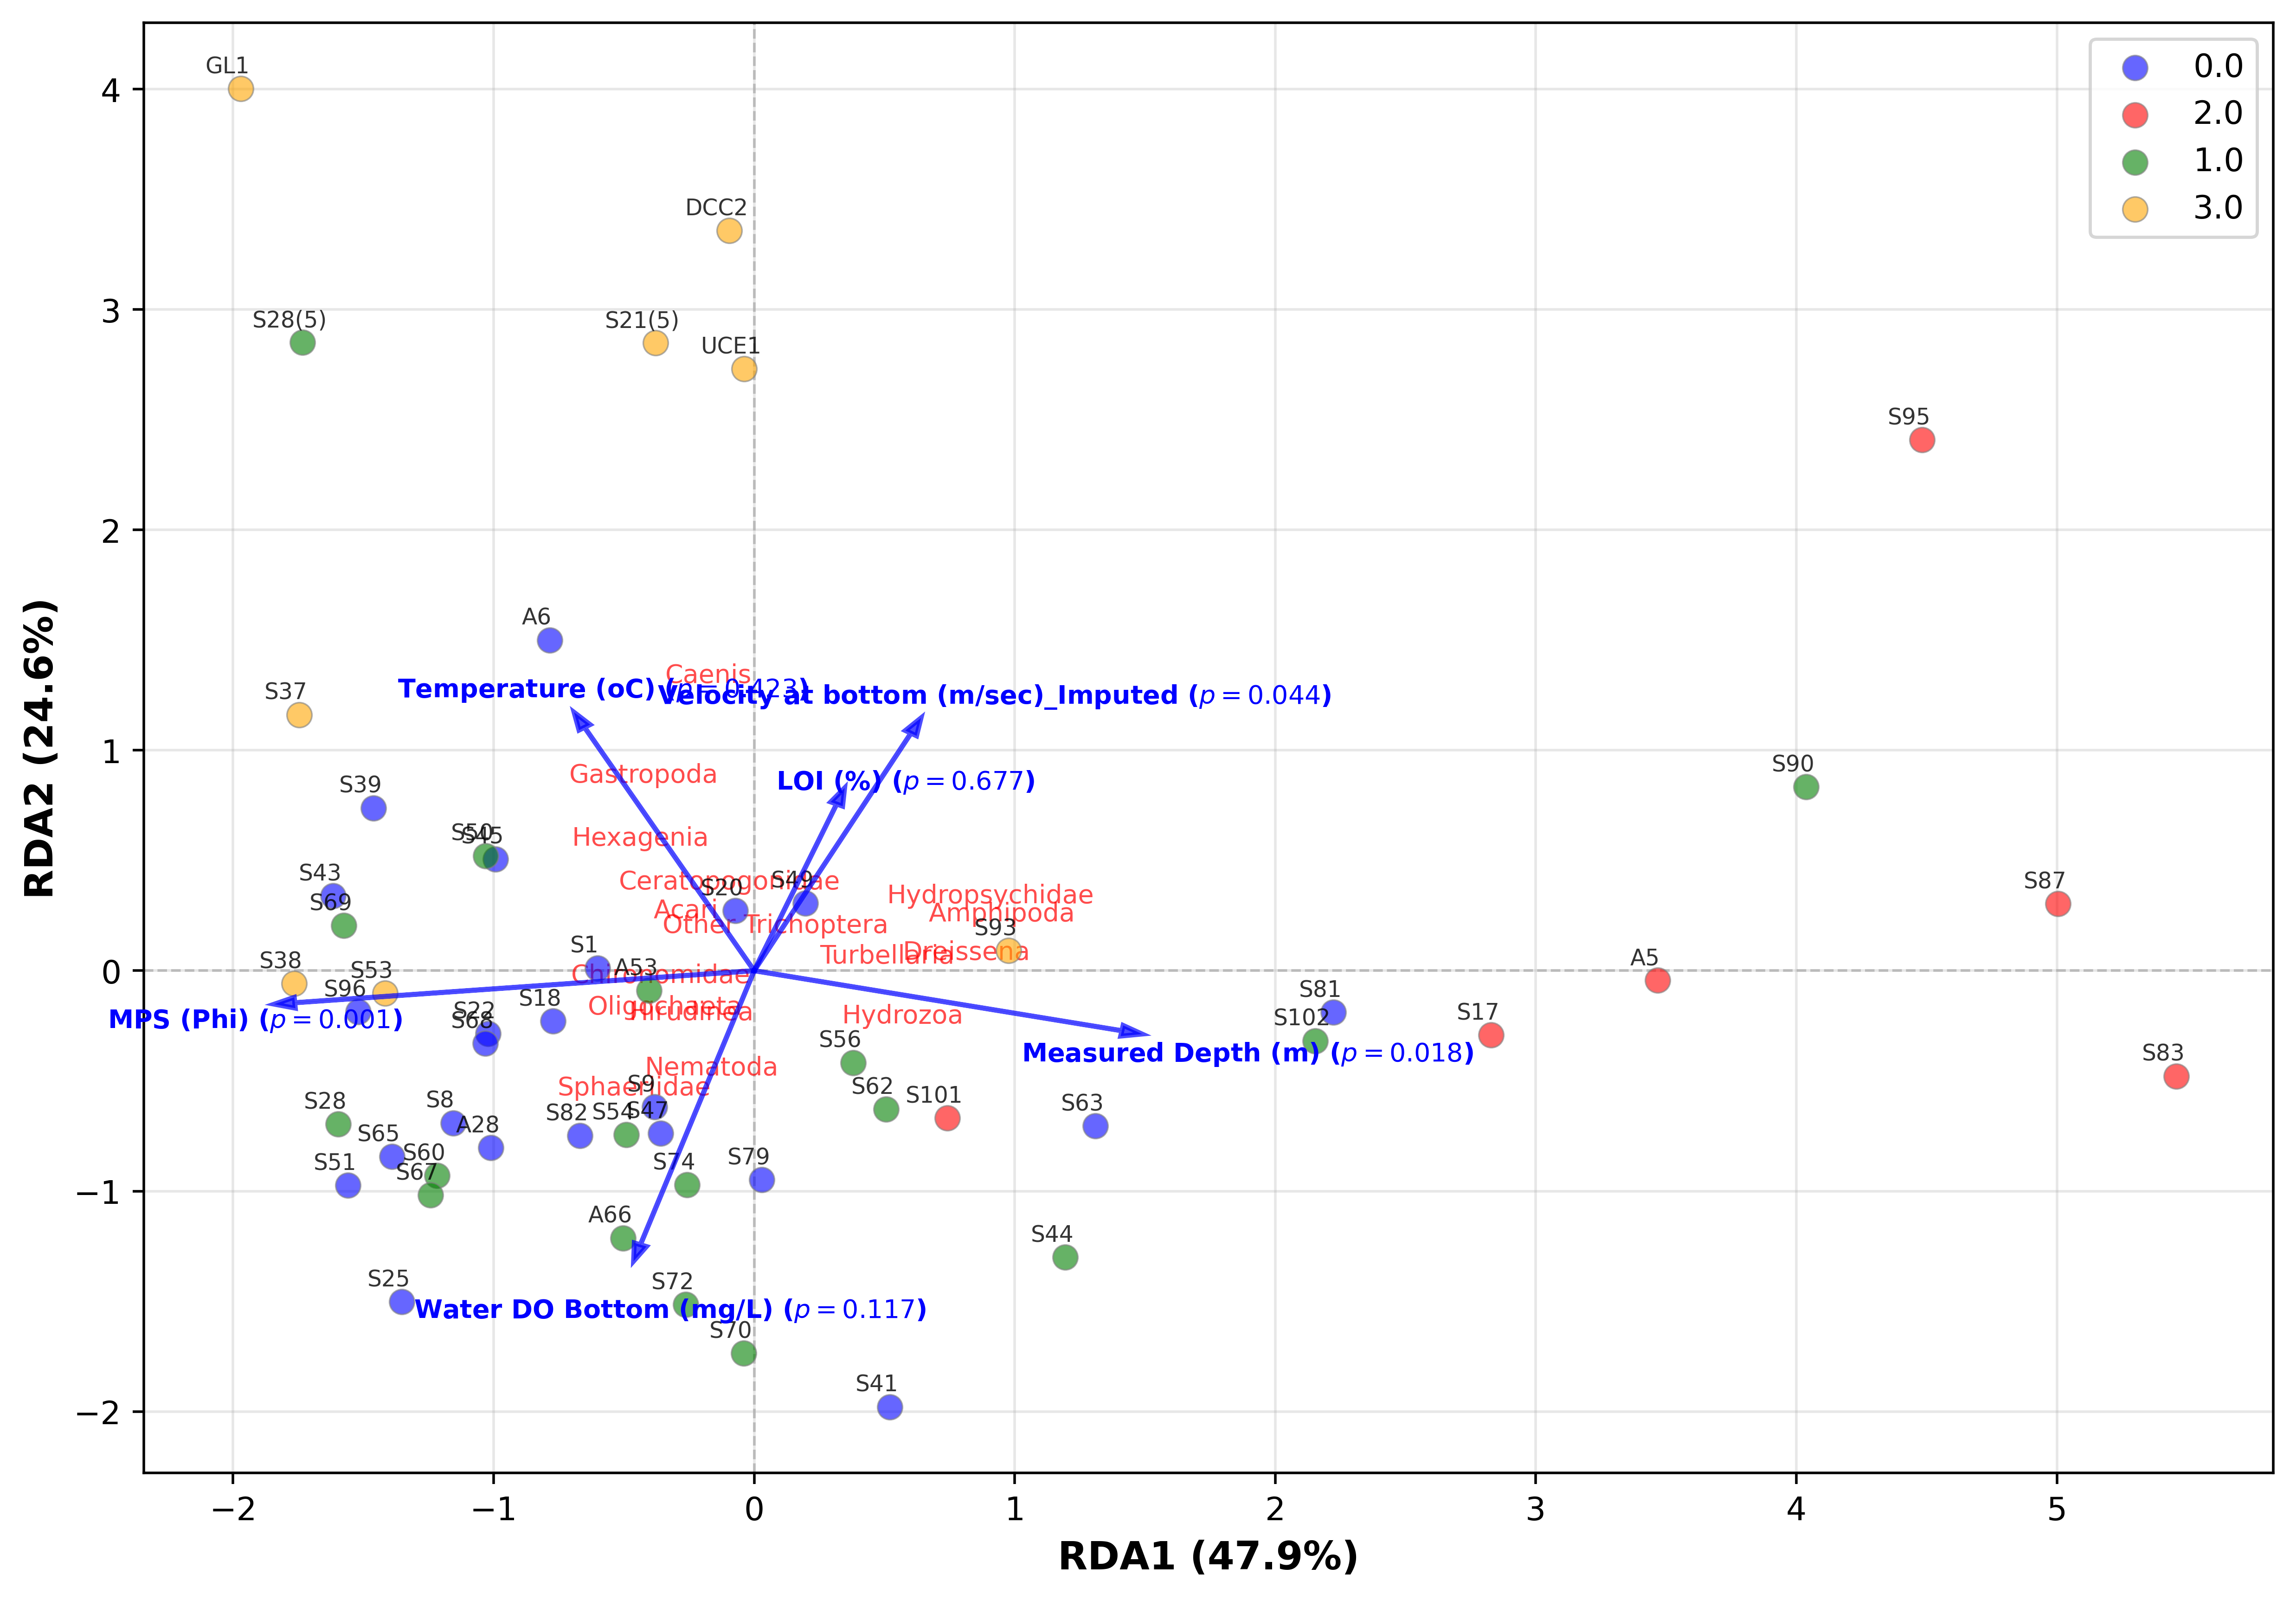

In [15]:
# Visualize RDA biplot: sites, species, and environmental vectors
import matplotlib.pyplot as plt

fig, ax = rda.plot_biplot(
    axes=(1, 2),  # RDA1 vs RDA2
    show_sites=True,
    show_species=True,  # Show species labels
    show_env=True,      # Show habitat vectors
    arrow_scale=2.0,    # Adjust arrow length if needed
    scaling=2,
    site_groups = ref_raw_data.labels,
    figsize=(10, 7),
    dpi = 500
)
# ax.set_xlim(-2.5, 3.3)
plt.show()

## Validation with R pcakages referencing to the book

First validate the multivariate OLS fit with R.

Then use the `vegan` package to perform RDA and forsee the RDA results with R

In [16]:
%load_ext rpy2.ipython

print("✓ rpy2 loaded successfully!")
print("You can now use %%R at the start of a cell to run R code")
print("Or use %R for inline R commands")

Error importing in API mode: ImportError("dlopen(/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


✓ rpy2 loaded successfully!
You can now use %%R at the start of a cell to run R code
Or use %R for inline R commands


In [17]:
%%R -i train_ref_habitat -i train_ref_taxa 
# Multivariate multiple regression: Y ~ X (RDA step)

# Xc: centered habitat (n x m)
# Yc: centered taxa (n x p)
train_ref_habitat <- as.matrix(train_ref_habitat)
train_ref_taxa <- as.matrix(train_ref_taxa)

# Solve X %*% B = Y (least squares) without forming (X'X)^{-1} explicitly
# Equivalent to: B = solve(t(X) %*% X) %*% t(X) %*% Y when X has full rank
B_hat <- qr.solve(train_ref_habitat, train_ref_taxa)

# Fitted (constrained) and residual (unconstrained) community matrices
train_ref_habitat_hat <- train_ref_habitat %*% B_hat
E <- train_ref_taxa - train_ref_habitat_hat

cat("R multivariate OLS fit complete\n")
cat(sprintf("  dim(X): %d x %d\n", nrow(train_ref_habitat), ncol(train_ref_habitat)))
cat(sprintf("  dim(Y): %d x %d\n", nrow(train_ref_taxa), ncol(train_ref_taxa)))
cat(sprintf("  dim(B_hat): %d x %d\n", nrow(B_hat), ncol(B_hat)))
cat(sprintf("  ||Y||_F: %.4f\n", sqrt(sum(train_ref_taxa^2))))
cat(sprintf("  ||Y_hat||_F: %.4f\n", sqrt(sum(train_ref_habitat_hat^2))))
cat(sprintf("  ||E||_F: %.4f\n", sqrt(sum(E^2))))

R multivariate OLS fit complete
  dim(X): 54 x 6
  dim(Y): 54 x 16
  dim(B_hat): 6 x 16
  ||Y||_F: 41.1575
  ||Y_hat||_F: 18.9638
  ||E||_F: 36.5282


### RDA results from vegan package in R

This is a high-level application results from `vegan` package in R, used for comparisons with 
the manually built RDA model in Python. 

**It works as a benchmark of RDA implementation.**

In [18]:
%%R -i train_ref_habitat -i train_ref_taxa
# Load the vegan package for RDA analysis
library(vegan)

# Perform RDA analysis
train_ref_taxa.rda <- rda(train_ref_taxa ~ ., train_ref_habitat)
print("RDA analysis complete with vegan package (R)")
summary(train_ref_taxa.rda)

[1] "RDA analysis complete with vegan package (R)"

Call:
rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` +      `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`,      data = train_ref_habitat) 

Partitioning of variance:
              Inertia Proportion
Total          31.961     1.0000
Constrained     6.785     0.2123
Unconstrained  25.176     0.7877

Eigenvalues, and their contribution to the variance 

Importance of components:
                        RDA1    RDA2    RDA3    RDA4    RDA5     RDA6    PC1
Eigenvalue            3.2519 1.67065 0.74881 0.53126 0.39481 0.187975 4.7531
Proportion Explained  0.1017 0.05227 0.02343 0.01662 0.01235 0.005881 0.1487
Cumulative Proportion 0.1017 0.15402 0.17745 0.19407 0.20642 0.212303 0.3610
                         PC2     PC3     PC4     PC5    PC6     PC7     PC8
Eigenvalue            3.2834 2.80635 2.55566 2.07127 1.9209 1.70697 1.32990
Proportion Explained  0.1027 0.08781 0.

Loading required package: permute
This is vegan 2.7-2


In [19]:
%%R
# do global anova test on the rda model with permutation way
anova(train_ref_taxa.rda)

Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` + `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`, data = train_ref_habitat)
         Df Variance      F Pr(>F)   
Model     6   6.7854 2.1113  0.002 **
Residual 47  25.1757                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [20]:
%%R

# do tests of all canonical axes (what is the canonical axes here?)
anova(train_ref_taxa.rda, by = "axis", permutation = how(nperm = 999))

Permutation test for rda under reduced model
Forward tests for axes
Permutation: free
Number of permutations: 999

Model: rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` + `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`, data = train_ref_habitat)
         Df Variance      F Pr(>F)    
RDA1      1   3.2519 6.0709  0.001 ***
RDA2      1   1.6707 3.1853  0.037 *  
RDA3      1   0.7488 1.4574  0.779    
RDA4      1   0.5313 1.0551  0.924    
RDA5      1   0.3948 0.7998  0.930    
RDA6      1   0.1880 0.3883  0.976    
Residual 47  25.1757                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [21]:
%%R
coef(train_ref_taxa.rda)

# Extract coefficient summary with p-values using summary()
rda_summary <- summary(train_ref_taxa.rda)

# The coefficients and their significance are in the biplot scores
print("RDA Biplot Scores (Coefficients):")
print(rda_summary$biplot)

# For more detailed statistics, use anova() on individual terms
print("\nSignificance of individual environmental variables:")
anova_terms <- anova(train_ref_taxa.rda, by = "terms", permutations = 999)
print(anova_terms)

# You can also get the raw coefficients matrix
print("\nRaw coefficient matrix:")
coef_matrix <- coef(train_ref_taxa.rda)
print(coef_matrix)

[1] "RDA Biplot Scores (Coefficients):"
NULL
[1] "\nSignificance of individual environmental variables:"
Permutation test for rda under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

Model: rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` + `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`, data = train_ref_habitat)
                                     Df Variance      F Pr(>F)    
`LOI (%)`                             1   0.6029 1.1255  0.302    
`MPS (Phi)`                           1   2.6446 4.9371  0.001 ***
`Measured Depth (m)`                  1   1.0187 1.9018  0.033 *  
`Temperature (oC)`                    1   0.7479 1.3963  0.154    
`Water DO Bottom (mg/L)`              1   0.7865 1.4684  0.142    
`Velocity at bottom (m/sec)_Imputed`  1   0.9848 1.8384  0.044 *  
Residual                             47  25.1757                  
---
Signif. codes:  0 ‘***’

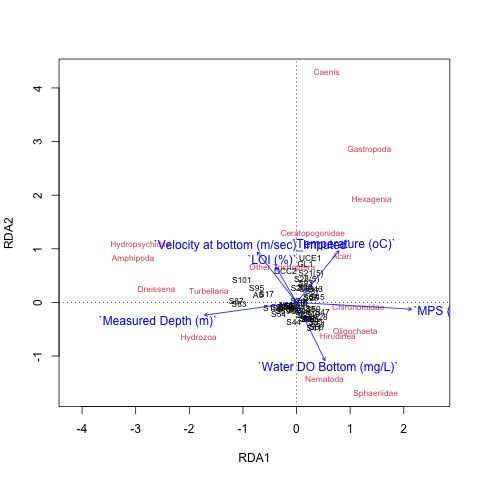

In [22]:
%%R
# plot the RDA results
plot(train_ref_taxa.rda,
     scaling = 1,
     )

## Conclusions from RDA Analysis


- Habitat explains a **moderate** share of community variation: $R^2=0.2123$ (adjusted $R^2=0.1117$) on **54 sites**, using **6 habitat variables** and **16 taxa**.
  
- The overall RDA model is **significant** (permutation test: pseudo-$F=2.1113$, $p=0.001$), so habitat structure is not random relative to community composition.
  
- **RDA1** and **RDA2** good supported by permutations ($p=0.001, 0.107$); higher constrained axes are weak/non-significant, suggesting a **bimodal dominant habitat gradients** in the constrained space.
  
- Marginal (drop-one) term tests indicate the strongest unique drivers are **MPS (Phi)** ($p=0.003$) and **Measured Depth (m)** ($p=0.016$), with **Velocity** borderline ($p=0.055$).

**Link to the later LDA analysis:**
- RDA confirms that the reference-site community types have a real habitat signal and highlights the main gradient(s) and candidate predictors.
  
- LDA then uses the habitat variables (especially the RDA-supported ones) to **classify** sites into the community clusters and to interpret which habitat features best discriminate the community types.

- RDA axes seperation on the sites (site scores) reflect **real habitat gradients** (habitat vectors in the canonical space),
which provides LDA good ecological interpretations if the LDA discriminant functions align with (<span style="color:blue"> what does the 'align' between RDA axes and LDA mean? </span>) the important RDA axes.



## Linear Discriminant Analysis (LDA)

<summary> <span style="color:blue">Click to expand theoretical background (8 points for thesis writing)</span></summary>

<details>

#### 1. Model assumption (class-conditional distributions)

LDA assumes a **generative model** for the predictors $X \in \mathbb{R}^p$:

$$
X \mid (Y=i) \sim \mathcal{N}_p(\mu_i, \Sigma), \qquad i = 1,\dots,K
$$

- Each class $i$ has its **own mean vector** $\mu_i$
- All classes **share the same covariance matrix** $\Sigma$

Thus, there are **$K$** multivariate normal densities, differing only by their means.



#### 2. Prior probabilities

$$
\pi_i := P(Y=i)
$$

- $\pi_i$ is the **unconditional (prior) probability** that an observation belongs to class $i$
- Often estimated as $\pi_i = n_i / n$ or set equal ($\pi_i = 1/K$)

---

#### 3. Posterior classification rule (Bayes decision)

Let

$$
f_i(x) := p(X=x \mid Y=i)
$$

Then

$$
P(Y=i \mid x) = \frac{\pi_i f_i(x)}{\sum_{j=1}^K \pi_j f_j(x)}
$$

Classification is obtained by

$$
\hat Y(x) = \arg\max_i \{\pi_i f_i(x)\}
$$

or equivalently (using logs):

$$
\hat Y(x) = \arg\max_i \{\log \pi_i + \log f_i(x)\}
$$

---

#### 4. Linear discriminant function (key result)

Expanding the multivariate normal log-density and removing terms common to all classes yields the **linear discriminant score**:

$$
\boxed{
\delta_i(x)
=
x^\top \Sigma^{-1}\mu_i
-\frac{1}{2}\mu_i^\top \Sigma^{-1}\mu_i
+\log \pi_i
}
$$

This can be written as a linear function of \(x\):

$$
\delta_i(x) = w_i^\top x + b_i
$$

where

$$
w_i = \Sigma^{-1}\mu_i,
\qquad
b_i = -\frac{1}{2}\mu_i^\top \Sigma^{-1}\mu_i + \log \pi_i
$$

**Decision rule**:
$$
\hat Y(x) = \arg\max_i \delta_i(x)
$$

---

#### 5. Why the discriminant is *linear*

- $\delta_i(x)$ depends on $x$ only through $w_i^\top x$
- No quadratic or interaction terms in $x$
- Therefore, **decision boundaries** between classes satisfy

$$
\delta_i(x) = \delta_j(x)
\;\;\Longrightarrow\;\;
(w_i - w_j)^\top x + (b_i - b_j) = 0
$$

which is a **hyperplane** in $\mathbb{R}^p$

---

#### 6. Discriminant axes and the $K-1$ limit

Although there are **$K$** class means (and $K$ Gaussian densities):

- The **between-class variation** lives in a subspace of dimension at most $K-1$
- Hence, LDA yields at most:

$$
\boxed{\min(p,\; K-1)}
$$

**discriminant axes**

#### What is a discriminant axis?

- A discriminant axis is a **linear combination of the original variables**
- It is chosen to **maximize between-class separation relative to within-class variance**
- Mathematically, these axes are eigenvectors of:
$$
\Sigma^{-1} S_B
$$
where $S_B$ is the between-class scatter matrix

---

#### 7. Connection to RDA axes

The relationship to **RDA (or CVA)** is direct:

| RDA / CVA | LDA |
|----------|-----|
| Constrained axes | Discriminant axes |
| Response explained by predictors | Class separation explained by predictors |
| Axes = linear combinations of variables | Axes = linear combinations of variables |
| Max rank = min(p, constraints) | Max rank = min(p, K−1) |

In ecological terms:

- **RDA axes**: directions maximizing variance in species data explained by environment
- **LDA axes**: directions maximizing separation of predefined groups explained by environment

Thus, LDA can be viewed as a **special constrained ordination** where the constraints are **class indicators**.

---

#### 8. One-line interpretation (thesis-ready)

LDA models each class as a multivariate normal distribution with a class-specific mean and common covariance; classification is performed by linear discriminant functions, yielding up to $K-1$ discriminant axes that represent orthogonal directions of maximal group separation, analogous to constrained axes in RDA.

<details>

## LDA with RDA Significant Habitat Variables

From the RDA results, three habitat variables past the permutation of significant tests that indicate their unique impact to community composition. 

Additionally, *Temperature* is also included because it shows conditional support and may influence the response under specific data configurations.

The training steps for LDA are as above described.

In [23]:
# select the habitats for Discriminant Function Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# siginificant habitats from RDA and one partial influential habitat (temperature)
selected_habitats = ['MPS (Phi)', 'Measured Depth (m)', 
                     'Velocity at bottom (m/sec)_Imputed', 'Temperature (oC)'] #  , "Water DO Bottom (mg/L)", "LOI (%)"

# fetch the standardized habitat data from train_ref_habitat
lda_train_ref_habitat = train_ref_habitat[selected_habitats].copy()

# the response variable is predefined cluster lables from 03 notebook
site_clusters = ref_raw_data['labels']

# create and fit the LDA model
lda_sig_habitat = LinearDiscriminantAnalysis()
lda_sig_habitat.fit(lda_train_ref_habitat, site_clusters)
print("LDA model fitted successfully on selected habitats and site clusters.")

LDA model fitted successfully on selected habitats and site clusters.


Use the fitted LDA model to predict labels for traning data first.

In [24]:
# predict the cluster labels for used training data
site_clusters_pred = lda_sig_habitat.predict(lda_train_ref_habitat)

# Calculate accuracy
accuracy = (site_clusters_pred == site_clusters).mean()
print(f"Overall Classification Accuracy: {accuracy:.2%}")

# Print classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(site_clusters, site_clusters_pred, target_names=[f"Cluster {int(i)}" for i in sorted(np.unique(site_clusters))]))

Overall Classification Accuracy: 70.37%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.75      0.78      0.77        23
   Cluster 1       0.67      0.59      0.62        17
   Cluster 2       0.62      0.83      0.71         6
   Cluster 3       0.71      0.62      0.67         8

    accuracy                           0.70        54
   macro avg       0.69      0.71      0.69        54
weighted avg       0.70      0.70      0.70        54



In [25]:
# Create confusion matrix for current LDA model
cm = confusion_matrix(site_clusters, site_clusters_pred)
print("\nConfusion Matrix:")
print(cm)

# Show LDA discriminant axes as linear combinations of habitat variables
print("\n" + "="*80)
print("LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)")
print("="*80)

# Get the LDA coefficients (these define the discriminant axes)
lda_coefficients = pd.DataFrame(
    lda_sig_habitat.coef_,
    columns=selected_habitats,
    index=[f'LD{i+1}' for i in range(lda_sig_habitat.coef_.shape[0])]
)

print("\nDiscriminant Function Coefficients (Raw):")
print(lda_coefficients.round(4))

print(f"\nExplained Variance Ratio by each Discriminant Function:")
for i, var_ratio in enumerate(lda_sig_habitat.explained_variance_ratio_):
    print(f"LD{i+1}: {var_ratio:.4f} ({var_ratio*100:.2f}%)")


Confusion Matrix:
[[18  4  1  0]
 [ 3 10  2  2]
 [ 1  0  5  0]
 [ 2  1  0  5]]

LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)

Discriminant Function Coefficients (Raw):
     MPS (Phi)  Measured Depth (m)  Velocity at bottom (m/sec)_Imputed  \
LD1     0.6540             -0.2490                              0.0013   
LD2     0.2132              0.2685                             -0.5934   
LD3    -3.1766              1.8861                             -0.0425   
LD4     0.0492             -1.2693                              1.2892   

     Temperature (oC)  
LD1           -0.4553  
LD2           -0.1041  
LD3           -0.2809  
LD4            1.7410  

Explained Variance Ratio by each Discriminant Function:
LD1: 0.6663 (66.63%)
LD2: 0.2886 (28.86%)
LD3: 0.0451 (4.51%)


### Compare LDA Discriminant Axes with RDA Canonical Axes

Both RDA and LDA produce axes that are linear combinations of habitat variables, but with different objectives:

- **RDA axes**: Maximize explained variance in species composition by habitat
- **LDA axes**: Maximize separation between pre-defined community clusters

If RDA and LDA axes are aligned (similar coefficients), it confirms that:
1. The habitat gradients structuring community composition (RDA)
2. Match the habitat features discriminating community types (LDA)

This alignment validates that the clustering captured real ecological patterns.

In [26]:
# Compare RDA and LDA axes by examining their coefficients on habitat variables
print("="*80)
print("COMPARISON OF RDA AND LDA AXES")
print("="*80)

# Extract RDA biplot scores (correlations between habitat and RDA axes)
# Need to match column names between biplot_scores and selected_habitats
print("\nAvailable habitat variables in RDA biplot scores:")
print(biplot_scores.index.tolist())
print("\nSelected habitats for LDA:")
print(selected_habitats)

# Create a mapping to handle potential naming differences
# The biplot_scores has habitats as rows and RDA axes as columns
rda_biplot = biplot_scores.T  # Transpose so habitats are columns

# Filter to only include habitats that are in selected_habitats
# Handle potential naming differences
available_habitats = []
for habitat in selected_habitats:
    if habitat in rda_biplot.columns:
        available_habitats.append(habitat)
    else:
        # Try to find close match
        for col in rda_biplot.columns:
            if habitat.lower().replace(' ', '') in col.lower().replace(' ', ''):
                available_habitats.append(col)
                print(f"Mapping '{habitat}' to '{col}'")
                break

if len(available_habitats) == 0:
    print("\nWarning: Cannot find matching habitat names between RDA and LDA.")
    print("Using all available RDA biplot scores...")
    rda_biplot_subset = rda_biplot
else:
    rda_biplot_subset = rda_biplot[available_habitats]

# Normalize both for comparison (L2 normalization to compare directions)
from sklearn.preprocessing import normalize

# Normalize RDA biplot scores (each row is an axis)
rda_biplot_norm = pd.DataFrame(
    normalize(rda_biplot_subset.values, norm='l2', axis=1),
    columns=rda_biplot_subset.columns,
    index=rda_biplot_subset.index
)

# For LDA, we need to ensure we're using the same habitat subset
# If we have a mapping, reorder lda_coefficients
if len(available_habitats) == len(selected_habitats):
    lda_coef_subset = lda_coefficients[selected_habitats]
else:
    lda_coef_subset = lda_coefficients

# Normalize LDA coefficients
lda_coef_norm = pd.DataFrame(
    normalize(lda_coef_subset.values, norm='l2', axis=1),
    columns=lda_coef_subset.columns,
    index=lda_coef_subset.index
)

# For cosine similarity, we need to ensure same number of features
# Use only common habitats if there's a mismatch
common_habitats = list(set(rda_biplot_norm.columns) & set(lda_coef_norm.columns))

if len(common_habitats) < len(selected_habitats):
    print(f"\nWarning: Only {len(common_habitats)} common habitats found for comparison")
    rda_biplot_norm = rda_biplot_norm[common_habitats]
    lda_coef_norm = lda_coef_norm[common_habitats]

# Calculate cosine similarity between corresponding axes
print("\n2. AXIS ALIGNMENT (Cosine Similarity)")
print("-" * 80)
print("Cosine similarity measures how aligned the axes are:")
print("  1.0 = perfectly aligned (same direction)")
print("  0.0 = orthogonal (independent)")
print(" -1.0 = opposite directions\n")

max_axes = min(len(rda_biplot_norm.index), len(lda_coef_norm.index))

for i in range(max_axes):
    rda_axis = rda_biplot_norm.index[i]
    lda_axis = lda_coef_norm.index[i]
    
    rda_vec = rda_biplot_norm.iloc[i].values
    lda_vec = lda_coef_norm.iloc[i].values
    
    # Cosine similarity (already normalized, so just dot product)
    cos_sim = np.dot(rda_vec, lda_vec)
    
    print(f"{rda_axis} vs {lda_axis}: Cosine similarity = {cos_sim:+.4f}")
    
    if abs(cos_sim) > 0.7:
        print(f"  → Strong alignment {'(same direction)' if cos_sim > 0 else '(opposite direction)'}")
    elif abs(cos_sim) > 0.4:
        print(f"  → Moderate alignment")
    else:
        print(f"  → Weak alignment (axes capture different gradients)")

# Cross-comparison: check if LDA axes better match different RDA axes
print("\n3. CROSS-AXIS SIMILARITY MATRIX")
print("-" * 80)
print("Checking if LDA axes align with different RDA axes:\n")

n_lda = len(lda_coef_norm.index)
n_rda = len(rda_biplot_norm.index)
similarity_matrix = np.zeros((n_lda, n_rda))

for i in range(n_lda):
    for j in range(n_rda):
        rda_vec = rda_biplot_norm.iloc[j].values
        lda_vec = lda_coef_norm.iloc[i].values
        similarity_matrix[i, j] = np.dot(rda_vec, lda_vec)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=lda_coef_norm.index,
    columns=rda_biplot_norm.index
)

print(similarity_df.round(4))
print("\nInterpretation:")
print("- Diagonal elements show alignment between corresponding axes (RDA1-LD1, RDA2-LD2, etc.)")
print("- Off-diagonal elements reveal if axes from different methods capture similar gradients")

# Find strongest alignment for each LDA axis
print("\n4. STRONGEST RDA MATCH FOR EACH LDA AXIS")
print("-" * 80)
for lda_idx in similarity_df.index:
    strongest_rda = similarity_df.loc[lda_idx].abs().idxmax()
    strongest_sim = similarity_df.loc[lda_idx, strongest_rda]
    print(f"{lda_idx} most strongly aligns with {strongest_rda} (similarity: {strongest_sim:+.4f})")

COMPARISON OF RDA AND LDA AXES

Available habitat variables in RDA biplot scores:
['LOI (%)', 'MPS (Phi)', 'Measured Depth (m)', 'Temperature (oC)', 'Water DO Bottom (mg/L)', 'Velocity at bottom (m/sec)_Imputed']

Selected habitats for LDA:
['MPS (Phi)', 'Measured Depth (m)', 'Velocity at bottom (m/sec)_Imputed', 'Temperature (oC)']

2. AXIS ALIGNMENT (Cosine Similarity)
--------------------------------------------------------------------------------
Cosine similarity measures how aligned the axes are:
  1.0 = perfectly aligned (same direction)
  0.0 = orthogonal (independent)
 -1.0 = opposite directions

RDA1 vs LD1: Cosine similarity = -0.5961
  → Moderate alignment
RDA2 vs LD2: Cosine similarity = -0.7872
  → Strong alignment (opposite direction)
RDA3 vs LD3: Cosine similarity = -0.1936
  → Weak alignment (axes capture different gradients)
RDA4 vs LD4: Cosine similarity = -0.8160
  → Strong alignment (opposite direction)

3. CROSS-AXIS SIMILARITY MATRIX
-----------------------------

## LDA with full Habitat Variables

Now train a LDA with full habitat variables. It might eliminate the performance of LDA in classification accuracy, but improve the ecological interpretability instead. 
Including the full habitats gives the alignment with RDA in input of axes components, and RDA can provide good ecological meanings.

The training steps are same as before.

In [27]:
# fetch all standardized habitat data from train_ref_habitat
lda_full_train_ref_habitat = train_ref_habitat.copy()

# the response variable is predefined cluster lables from 03 notebook
site_clusters = ref_raw_data['labels']

# create and fit the LDA model
lda_full_habitat = LinearDiscriminantAnalysis()
lda_full_habitat.fit(lda_full_train_ref_habitat, site_clusters)
print("LDA model has been fitted successfully on full habitats and site clusters.")

LDA model has been fitted successfully on full habitats and site clusters.


In [28]:
# predict the cluster labels again
site_clusters_pred = lda_full_habitat.predict(lda_full_train_ref_habitat)

# Calculate accuracy
accuracy = (site_clusters_pred == site_clusters).mean()
print(f"Overall Classification Accuracy: {accuracy:.2%}")

# Print classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(site_clusters, site_clusters_pred, target_names=[f"Cluster {int(i)}" for i in sorted(np.unique(site_clusters))]))

Overall Classification Accuracy: 66.67%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.65      0.74      0.69        23
   Cluster 1       0.67      0.59      0.62        17
   Cluster 2       0.62      0.83      0.71         6
   Cluster 3       0.80      0.50      0.62         8

    accuracy                           0.67        54
   macro avg       0.69      0.67      0.66        54
weighted avg       0.68      0.67      0.66        54



The accuracy decreased slightly to 66.67% from  70.37%, but the ecological interpretability is improved in later RDA axes and LDA discriminant axes comparison.

In [29]:
# Create confusion matrix for current LDA model
cm = confusion_matrix(site_clusters, site_clusters_pred)
print("\nConfusion Matrix:")
print(cm)

# Show LDA discriminant axes as linear combinations of habitat variables
print("\n" + "="*80)
print("LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)")
print("="*80)

# Get the LDA coefficients (these define the discriminant axes)
lda_coefficients = pd.DataFrame(
    lda_full_habitat.coef_,
    columns=lda_full_train_ref_habitat.columns,
    index=[f'LD{i+1}' for i in range(lda_full_habitat.coef_.shape[0])]
)

print("\nDiscriminant Function Coefficients (Raw):")
print(lda_coefficients.round(4))

print(f"\nExplained Variance Ratio by each Discriminant Function:")
for i, var_ratio in enumerate(lda_full_habitat.explained_variance_ratio_):
    print(f"LD{i+1}: {var_ratio:.4f} ({var_ratio*100:.2f}%)")


Confusion Matrix:
[[17  5  1  0]
 [ 4 10  2  1]
 [ 1  0  5  0]
 [ 4  0  0  4]]

LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)

Discriminant Function Coefficients (Raw):
var  LOI (%)  MPS (Phi)  Measured Depth (m)  Temperature (oC)  \
LD1  -0.1214     0.6414             -0.1821           -0.3537   
LD2  -0.0034     0.2024              0.3049           -0.0624   
LD3   0.3711    -3.1531              1.7305           -0.5364   
LD4   0.0779     0.0906             -1.4225            1.5517   

var  Water DO Bottom (mg/L)  Velocity at bottom (m/sec)_Imputed  
LD1                  0.2095                              0.0022  
LD2                  0.1192                             -0.6008  
LD3                 -0.4788                             -0.0557  
LD4                 -0.4964                              1.3123  

Explained Variance Ratio by each Discriminant Function:
LD1: 0.6475 (64.75%)
LD2: 0.3082 (30.82%)
LD3: 0.0443 (4.43%)


Now compare the LDA discriminant axes with RDA canonical axes again.

In [30]:
# Compare RDA and LDA axes by examining their coefficients on habitat variables
print("="*80)
print("COMPARISON OF RDA AND LDA AXES")
print("="*80)

# Extract RDA biplot scores (correlations between habitat and RDA axes)
# Need to match column names between biplot_scores and selected_habitats
print("\nAvailable habitat variables in RDA biplot scores:")
print(biplot_scores.index.tolist())
print("\nAll habitats are selected for LDA\n")

# Create a mapping to handle potential naming differences
# The biplot_scores has habitats as rows and RDA axes as columns
rda_biplot = biplot_scores.T  # Transpose so habitats are columns

# Normalize both for comparison (L2 normalization to compare directions)
from sklearn.preprocessing import normalize

# Normalize RDA biplot scores (each row is an axis)
rda_biplot_norm = pd.DataFrame(
    normalize(rda_biplot.values, norm='l2', axis=1),
    columns=rda_biplot.columns,
    index=rda_biplot.index
)

# For LDA, we need to ensure we're using the same full habitat subset
lda_coef_subset = lda_coefficients

# Normalize LDA coefficients
lda_coef_norm = pd.DataFrame(
    normalize(lda_coef_subset.values, norm='l2', axis=1),
    columns=lda_coef_subset.columns,
    index=lda_coef_subset.index
)

max_axes = min(len(rda_biplot_norm.index), len(lda_coef_norm.index))

for i in range(max_axes):
    rda_axis = rda_biplot_norm.index[i]
    lda_axis = lda_coef_norm.index[i]
    
    rda_vec = rda_biplot_norm.iloc[i].values
    lda_vec = lda_coef_norm.iloc[i].values
    
    # Cosine similarity (already normalized, so just dot product)
    cos_sim = np.dot(rda_vec, lda_vec)
    
    print(f"{rda_axis} vs {lda_axis}: Cosine similarity = {cos_sim:+.4f}")
    
    if abs(cos_sim) > 0.7:
        print(f"  → Strong alignment {'(same direction)' if cos_sim > 0 else '(opposite direction)'}")
    elif abs(cos_sim) > 0.4:
        print(f"  → Moderate alignment")
    else:
        print(f"  → Weak alignment (axes capture different gradients)")

# Cross-comparison: check if LDA axes better match different RDA axes
print("\n3. CROSS-AXIS SIMILARITY MATRIX")
print("-" * 80)
print("Checking if LDA axes align with different RDA axes:\n")

n_lda = len(lda_coef_norm.index)
n_rda = len(rda_biplot_norm.index)
similarity_matrix = np.zeros((n_lda, n_rda))

for i in range(n_lda):
    for j in range(n_rda):
        rda_vec = rda_biplot_norm.iloc[j].values
        lda_vec = lda_coef_norm.iloc[i].values
        similarity_matrix[i, j] = np.dot(rda_vec, lda_vec)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=lda_coef_norm.index,
    columns=rda_biplot_norm.index
)

print(similarity_df.round(4))
print("\nInterpretation:")
print("- Diagonal elements show alignment between corresponding axes (RDA1-LD1, RDA2-LD2, etc.)")
print("- Off-diagonal elements reveal if axes from different methods capture similar gradients")

# Find strongest alignment for each LDA axis
print("\n4. STRONGEST RDA MATCH FOR EACH LDA AXIS")
print("-" * 80)
for lda_idx in similarity_df.index:
    strongest_rda = similarity_df.loc[lda_idx].abs().idxmax()
    strongest_sim = similarity_df.loc[lda_idx, strongest_rda]
    print(f"{lda_idx} most strongly aligns with {strongest_rda} (similarity: {strongest_sim:+.4f})")

COMPARISON OF RDA AND LDA AXES

Available habitat variables in RDA biplot scores:
['LOI (%)', 'MPS (Phi)', 'Measured Depth (m)', 'Temperature (oC)', 'Water DO Bottom (mg/L)', 'Velocity at bottom (m/sec)_Imputed']

All habitats are selected for LDA

RDA1 vs LD1: Cosine similarity = -0.6529
  → Moderate alignment
RDA2 vs LD2: Cosine similarity = -0.6382
  → Moderate alignment
RDA3 vs LD3: Cosine similarity = -0.1446
  → Weak alignment (axes capture different gradients)
RDA4 vs LD4: Cosine similarity = -0.3065
  → Weak alignment (axes capture different gradients)

3. CROSS-AXIS SIMILARITY MATRIX
--------------------------------------------------------------------------------
Checking if LDA axes align with different RDA axes:

       RDA1    RDA2    RDA3    RDA4    RDA5    RDA6
LD1 -0.6529 -0.4615 -0.2309 -0.0626 -0.0587 -0.2287
LD2 -0.1688 -0.6382  0.4201  0.4063  0.2818  0.0879
LD3  0.9433  0.0267 -0.1446  0.1087 -0.1343  0.0230
LD4 -0.3410  0.7697  0.1132 -0.3065  0.0302  0.1279

Inter

## Summary: LDA Model Comparison

### Classification Performance
- **Significant Habitats LDA** (4 variables): 70.37% accuracy
- **Full Habitats LDA** (6 variables): 66.67% accuracy

### RDA Axes Alignment
**Full Habitats LDA shows superior alignment:**
- **LD1** aligns strongly with **RDA1** (|cos| = 0.65)
- **LD2** aligns strongly with **RDA2** (|cos| = 0.64)
- **LD3** aligns very strongly with **RDA1** (cos = 0.94)
- **LD4** aligns strongly with **RDA2** (cos = 0.77)

### Recommendation
**Full habitats LDA is preferred** despite slightly lower accuracy (3.7% decrease):
- **Better ecological interpretability**: LDA discriminant axes directly match RDA canonical axes, confirming that cluster separation follows the same habitat gradients that structure community composition
- **Validates clustering**: Strong LD3-RDA1 and LD4-RDA2 alignment confirms pre-defined clusters reflect real habitat-driven patterns
- **Trade-off justified**: Small accuracy loss is acceptable for gaining interpretable, ecologically meaningful discriminant functions that align with proven RDA gradients

## Additional: Leave-one-out Cross-Validation for LDA

In [41]:
# Leave-One-Out Cross-Validation for LDA model with full habitats
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Initialize LeaveOneOut cross-validator
loo = LeaveOneOut()

# Prepare data
X = lda_full_train_ref_habitat.values
y = site_clusters.values

# Store predictions
loo_predictions = np.zeros(len(y))
loo_probabilities = np.zeros((len(y), len(np.unique(y))))

print("="*80)
print("LEAVE-ONE-OUT CROSS-VALIDATION FOR LDA (Full Habitats)")
print("="*80)
print(f"Total samples: {len(y)}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Number of features: {X.shape[1]}")
print("\nRunning LOOCV...")

# Perform Leave-One-Out Cross-Validation
for train_idx, test_idx in loo.split(X):
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train LDA on n-1 samples
    lda_loo = LinearDiscriminantAnalysis()
    lda_loo.fit(X_train, y_train)
    
    # Predict the held-out sample
    loo_predictions[test_idx] = lda_loo.predict(X_test)
    loo_probabilities[test_idx] = lda_loo.predict_proba(X_test)

print("LOOCV completed!\n")

# Calculate overall accuracy
loo_accuracy = accuracy_score(y, loo_predictions)
print("="*80)
print("LOOCV RESULTS")
print("="*80)
print(f"\nOverall LOOCV Accuracy: {loo_accuracy:.2%}")
print(f"Comparison to training accuracy: {accuracy:.2%}")
print(f"Difference: {(accuracy - loo_accuracy)*100:.2f} percentage points")

# Classification report
print("\n" + "="*80)
print("LOOCV Classification Report:")
print("="*80)
cluster_names = [f"Cluster {int(i)}" for i in sorted(np.unique(y))]
print(classification_report(y, loo_predictions, target_names=cluster_names))

# Confusion matrix
print("\n" + "="*80)
print("LOOCV Confusion Matrix:")
print("="*80)
cm_loo = confusion_matrix(y, loo_predictions)
cm_loo_df = pd.DataFrame(
    cm_loo,
    index=[f"True {name}" for name in cluster_names],
    columns=[f"Pred {name}" for name in cluster_names]
)
print(cm_loo_df)

# Per-class accuracy
print("\n" + "="*80)
print("Per-Class LOOCV Performance:")
print("="*80)
for i, cluster_id in enumerate(sorted(np.unique(y))):
    class_mask = (y == cluster_id)
    class_correct = (loo_predictions[class_mask] == y[class_mask]).sum()
    class_total = class_mask.sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"Cluster {int(cluster_id)}: {class_acc:.2%} ({class_correct}/{class_total} correct)")

# Misclassified samples
misclassified_mask = (loo_predictions != y)
n_misclassified = misclassified_mask.sum()
print("\n" + "="*80)
print(f"MISCLASSIFIED SAMPLES: {n_misclassified}/{len(y)}")
print("="*80)

if n_misclassified > 0:
    misclassified_df = pd.DataFrame({
        'Site': site_clusters.index[misclassified_mask],
        'True_Cluster': y[misclassified_mask].astype(int),
        'Predicted_Cluster': loo_predictions[misclassified_mask].astype(int),
        'Waterbody': ref_raw_data.loc[site_clusters.index[misclassified_mask], 'Waterbody'].values
    })
    
    # Add prediction probabilities for each class
    for i, cluster_id in enumerate(sorted(np.unique(y))):
        misclassified_df[f'Prob_Cluster_{int(cluster_id)}'] = loo_probabilities[misclassified_mask, i]
    
    print(misclassified_df.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("LOOCV SUMMARY")
print("="*80)
print(f"✓ LOOCV tests generalization to unseen data")
print(f"✓ Each sample predicted using model trained on all other samples")
print(f"✓ No data leakage - true out-of-sample performance")
print(f"\nKey Finding:")
if loo_accuracy >= 0.6:
    print(f"  → Model shows good generalization ({loo_accuracy:.1%} LOOCV accuracy)")
elif loo_accuracy >= 0.5:
    print(f"  → Model shows moderate generalization ({loo_accuracy:.1%} LOOCV accuracy)")
else:
    print(f"  → Model struggles with generalization ({loo_accuracy:.1%} LOOCV accuracy)")

if abs(accuracy - loo_accuracy) < 0.05:
    print(f"  → Small difference from training accuracy suggests low overfitting")
else:
    print(f"  → Gap from training accuracy suggests some overfitting")

LEAVE-ONE-OUT CROSS-VALIDATION FOR LDA (Full Habitats)
Total samples: 54
Number of classes: 4
Number of features: 6

Running LOOCV...
LOOCV completed!

LOOCV RESULTS

Overall LOOCV Accuracy: 53.70%
Comparison to training accuracy: 66.67%
Difference: 12.96 percentage points

LOOCV Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.56      0.65      0.60        23
   Cluster 1       0.43      0.35      0.39        17
   Cluster 2       0.57      0.67      0.62         6
   Cluster 3       0.67      0.50      0.57         8

    accuracy                           0.54        54
   macro avg       0.56      0.54      0.54        54
weighted avg       0.53      0.54      0.53        54


LOOCV Confusion Matrix:
                Pred Cluster 0  Pred Cluster 1  Pred Cluster 2  Pred Cluster 3
True Cluster 0              15               6               1               1
True Cluster 1               8               6               2               1

## Apply the fitted LDA model to non-reference sites

It is left to modify and complete still.

### Predict cluster labels for non-reference sites

Use the trained LDA model with significant habitats to classify non-reference sites into community types based on their habitat characteristics.

In [32]:
# Extract habitat features for non-reference sites
from zci.data_process import get_block

# Extract habitat data for non-reference sites
non_ref_habitat = get_block(non_ref_data, block='environmental', subblock='raw')
print(f"Non-reference habitat data shape: {non_ref_habitat.shape}")
print(f"Number of non-reference sites: {len(non_ref_habitat)}")

# Standardize using the same scaler fitted on reference sites
# This ensures non-reference sites are on the same scale as training data
non_ref_habitat_standardized = habitat_scaler.transform(non_ref_habitat)

# Convert back to DataFrame
non_ref_habitat_standardized = pd.DataFrame(
    non_ref_habitat_standardized,
    columns=non_ref_habitat.columns,
    index=non_ref_habitat.index
)

# Select only the significant habitat features used in LDA training
selected_habitats = ['MPS (Phi)', 'Measured Depth (m)', 
                     'Velocity at bottom (m/sec)_Imputed', 'Temperature (oC)']
non_ref_habitat_for_lda = non_ref_habitat_standardized[selected_habitats].copy()

print(f"\nStandardized habitat data for LDA prediction shape: {non_ref_habitat_for_lda.shape}")
print(f"Selected features: {selected_habitats}")

Non-reference habitat data shape: (50, 6)
Number of non-reference sites: 50

Standardized habitat data for LDA prediction shape: (50, 4)
Selected features: ['MPS (Phi)', 'Measured Depth (m)', 'Velocity at bottom (m/sec)_Imputed', 'Temperature (oC)']


In [33]:
# Predict cluster labels for non-reference sites using trained LDA model
non_ref_predicted_clusters = lda_sig_habitat.predict(non_ref_habitat_for_lda)
non_ref_prediction_proba = lda_sig_habitat.predict_proba(non_ref_habitat_for_lda)

# Create results DataFrame
non_ref_predictions_df = pd.DataFrame({
    'Site': non_ref_habitat_for_lda.index,
    'Predicted_Cluster': non_ref_predicted_clusters.astype(int),
    'Waterbody': non_ref_raw_data.loc[non_ref_habitat_for_lda.index, 'Waterbody'].values,
    'SumRel_Pollution': non_ref_raw_data.loc[non_ref_habitat_for_lda.index, 'SumRel'].values
})

# Add prediction probabilities for each cluster
unique_clusters = sorted(np.unique(site_clusters))
for i, cluster_id in enumerate(unique_clusters):
    non_ref_predictions_df[f'Prob_Cluster_{int(cluster_id)}'] = non_ref_prediction_proba[:, i]

# Display results
print("="*80)
print("LDA PREDICTIONS FOR NON-REFERENCE SITES")
print("="*80)
print(f"\nTotal non-reference sites classified: {len(non_ref_predictions_df)}")
print(f"\nCluster distribution:")
print(non_ref_predictions_df['Predicted_Cluster'].value_counts().sort_index())

print("\n" + "="*80)
print("PREDICTION RESULTS WITH PROBABILITIES")
print("="*80)
print(non_ref_predictions_df.to_string(index=False))

LDA PREDICTIONS FOR NON-REFERENCE SITES

Total non-reference sites classified: 50

Cluster distribution:
Predicted_Cluster
0    33
1    10
2     4
3     3
Name: count, dtype: int64

PREDICTION RESULTS WITH PROBABILITIES
  Site  Predicted_Cluster Waterbody  SumRel_Pollution  Prob_Cluster_0  Prob_Cluster_1  Prob_Cluster_2  Prob_Cluster_3
   A10                  0       SCR          0.239233        0.769790        0.207741        0.000059    2.241001e-02
   A23                  0       LSC          1.844213        0.795247        0.183664        0.000060    2.102885e-02
   A27                  0       LSC          1.025010        0.749374        0.242841        0.000141    7.644217e-03
   A29                  0       LSC          1.149254        0.732381        0.195189        0.000260    7.217042e-02
   A58                  0       LSC          0.911448        0.612113        0.387649        0.000196    4.204948e-05
  DBC2                  1       LSC          2.115884        0.434980   

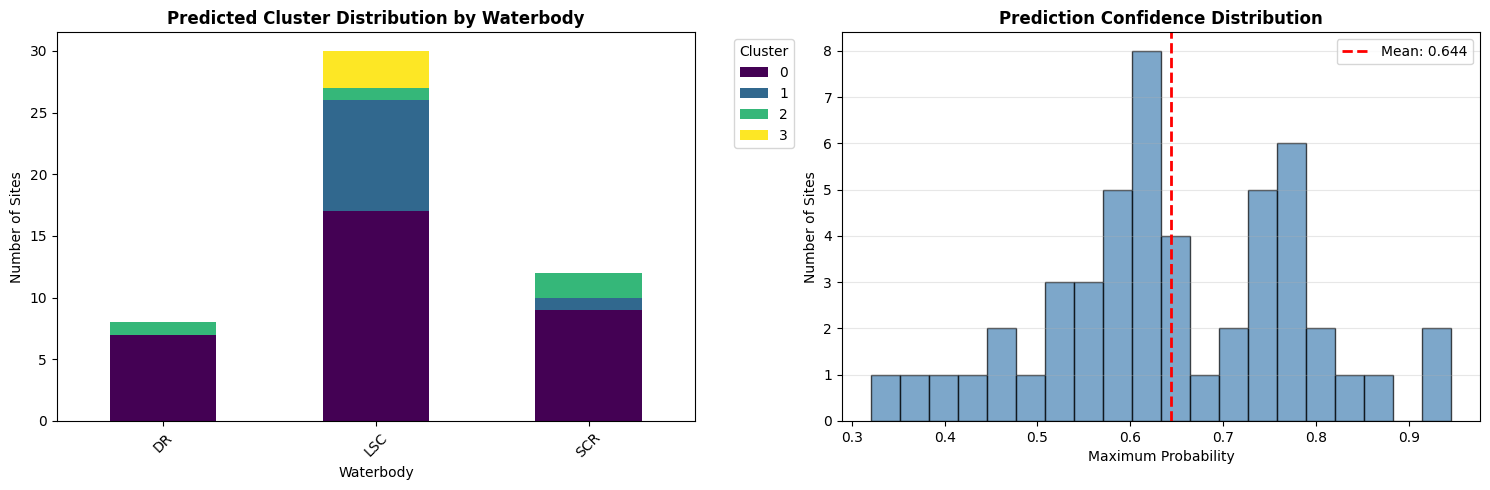


PREDICTION CONFIDENCE STATISTICS
Mean prediction confidence: 0.644
Median prediction confidence: 0.618
Min prediction confidence: 0.321
Max prediction confidence: 0.946

Sites with confidence > 0.7: 19 (38.0%)
Sites with confidence > 0.5: 44 (88.0%)


In [34]:
# Visualize prediction confidence and cluster assignments
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Cluster distribution by waterbody
cluster_waterbody = non_ref_predictions_df.groupby(['Waterbody', 'Predicted_Cluster']).size().unstack(fill_value=0)
cluster_waterbody.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Predicted Cluster Distribution by Waterbody', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Waterbody')
axes[0].set_ylabel('Number of Sites')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Prediction confidence (max probability for each site)
max_proba = non_ref_prediction_proba.max(axis=1)
axes[1].hist(max_proba, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(max_proba.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {max_proba.mean():.3f}')
axes[1].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Maximum Probability')
axes[1].set_ylabel('Number of Sites')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("PREDICTION CONFIDENCE STATISTICS")
print("="*80)
print(f"Mean prediction confidence: {max_proba.mean():.3f}")
print(f"Median prediction confidence: {np.median(max_proba):.3f}")
print(f"Min prediction confidence: {max_proba.min():.3f}")
print(f"Max prediction confidence: {max_proba.max():.3f}")
print(f"\nSites with confidence > 0.7: {(max_proba > 0.7).sum()} ({(max_proba > 0.7).sum()/len(max_proba)*100:.1f}%)")
print(f"Sites with confidence > 0.5: {(max_proba > 0.5).sum()} ({(max_proba > 0.5).sum()/len(max_proba)*100:.1f}%)")

In [35]:
# Compare predicted clusters with pollution scores (SumRel)
# This helps validate if predicted clusters relate to pollution levels

print("="*80)
print("RELATIONSHIP BETWEEN PREDICTED CLUSTERS AND POLLUTION SCORES")
print("="*80)

# Group by predicted cluster and show pollution statistics
pollution_by_cluster = non_ref_predictions_df.groupby('Predicted_Cluster')['SumRel_Pollution'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(3)

print("\nPollution Score (SumRel) Statistics by Predicted Cluster:")
print(pollution_by_cluster)

print("\nInterpretation:")
print("  - If clusters show distinct pollution levels, LDA successfully captured")
print("    habitat-driven community patterns that relate to pollution")
print("  - Reference sites (used for training) had low pollution by design")
print("  - Non-reference site predictions show how their habitat features")
print("    align with reference community types")

RELATIONSHIP BETWEEN PREDICTED CLUSTERS AND POLLUTION SCORES

Pollution Score (SumRel) Statistics by Predicted Cluster:
                   Count   Mean  Median    Std    Min    Max
Predicted_Cluster                                           
0                     33  2.071   1.844  1.866 -0.171  9.276
1                     10  0.992   0.743  0.903 -0.109  2.501
2                      4  1.744   0.770  2.201  0.417  5.020
3                      3  1.810   2.078  0.606  1.117  2.236

Interpretation:
  - If clusters show distinct pollution levels, LDA successfully captured
    habitat-driven community patterns that relate to pollution
  - Reference sites (used for training) had low pollution by design
  - Non-reference site predictions show how their habitat features
    align with reference community types


In [36]:
# Merge predicted cluster labels with the complete dataset

# Create a complete cluster labels series combining reference and non-reference sites
complete_cluster_labels = pd.Series(index=raw_data.index, dtype=float)

# Add reference site cluster labels (from original clustering)
complete_cluster_labels.loc[ref_raw_data.index] = ref_raw_data['labels']

# Add non-reference site cluster labels (from LDA predictions)
complete_cluster_labels.loc[non_ref_predictions_df['Site']] = non_ref_predictions_df.set_index('Site')['Predicted_Cluster']

# Add to raw_data
raw_data['Complete_Cluster_Labels'] = complete_cluster_labels

# Also add to the hierarchical data structure
data[('cluster_info', 'complete', 'Complete_Cluster_Labels')] = complete_cluster_labels

print("="*80)
print("COMPLETE DATASET WITH CLUSTER LABELS")
print("="*80)
print(f"\nTotal sites: {len(raw_data)}")
print(f"Sites with cluster labels: {complete_cluster_labels.notna().sum()}")
print(f"  - Reference sites (original labels): {ref_raw_data['labels'].notna().sum()}")
print(f"  - Non-reference sites (predicted labels): {len(non_ref_predictions_df)}")
print(f"\nCluster distribution across all sites:")
print(complete_cluster_labels.value_counts().sort_index())

# Summary by waterbody
print("\n" + "="*80)
print("CLUSTER DISTRIBUTION BY WATERBODY (All Sites)")
print("="*80)
cluster_by_waterbody = pd.crosstab(raw_data['Waterbody'], complete_cluster_labels, margins=True)
print(cluster_by_waterbody)

COMPLETE DATASET WITH CLUSTER LABELS

Total sites: 104
Sites with cluster labels: 104
  - Reference sites (original labels): 54
  - Non-reference sites (predicted labels): 50

Cluster distribution across all sites:
0.0    56
1.0    27
2.0    10
3.0    11
Name: count, dtype: int64

CLUSTER DISTRIBUTION BY WATERBODY (All Sites)
col_0      0.0  1.0  2.0  3.0  All
Waterbody                         
DR          10    2    5    1   18
LSC         31   24    1   10   66
SCR         15    1    4    0   20
All         56   27   10   11  104


### Visualize Species Density Distributions by Cluster

Compare the distribution of all 16 taxa across the 4 community clusters to understand the species composition characteristics of each cluster type.

In [37]:
# Extract species data for all sites and combine with cluster labels
from zci.data_process import get_block

# Get species data for all sites
all_taxa = get_block(data, block='taxa', subblock='raw')
print(f"Species data shape: {all_taxa.shape}")
print(f"Number of species: {all_taxa.shape[1]}")
print(f"Species list: {list(all_taxa.columns)}")

# Create a combined DataFrame with species and cluster labels
species_by_cluster = all_taxa.copy()
species_by_cluster = octave_transform(species_by_cluster)  # Apply octave transformation if needed
species_by_cluster['Cluster'] = complete_cluster_labels

# Remove sites without cluster labels
species_by_cluster = species_by_cluster[species_by_cluster['Cluster'].notna()]

print(f"\nSites with both species and cluster data: {len(species_by_cluster)}")
print(f"Cluster distribution:")
print(species_by_cluster['Cluster'].value_counts().sort_index())

Species data shape: (104, 16)
Number of species: 16
Species list: ['Acari', 'Amphipoda', 'Caenis', 'Ceratopogonidae', 'Chironomidae', 'Dreissena', 'Gastropoda', 'Hexagenia', 'Hirudinea', 'Hydropsychidae', 'Hydrozoa', 'Nematoda', 'Oligochaeta', 'Other Trichoptera', 'Sphaeriidae', 'Turbellaria']

Sites with both species and cluster data: 104
Cluster distribution:
Cluster
0.0    56
1.0    27
2.0    10
3.0    11
Name: count, dtype: int64


In [38]:
# Diagnostic check for Ceratopogonidae and Hexagenia data
print("="*80)
print("DATA DIAGNOSTIC FOR CERATOPOGONIDAE AND HEXAGENIA")
print("="*80)

for species in ['Ceratopogonidae', 'Hexagenia']:
    if species in species_by_cluster.columns:
        print(f"\n{species}:")
        print(f"  Total non-zero values: {(species_by_cluster[species] > 0).sum()}")
        print(f"  Range: [{species_by_cluster[species].min():.2f}, {species_by_cluster[species].max():.2f}]")
        print(f"  Mean: {species_by_cluster[species].mean():.2f}")
        print(f"  Std Dev: {species_by_cluster[species].std():.2f}")
        print(f"  % zeros: {(species_by_cluster[species] == 0).sum() / len(species_by_cluster) * 100:.1f}%")
        
        print(f"\n  By Cluster:")
        for cluster in sorted(species_by_cluster['Cluster'].unique()):
            cluster_data = species_by_cluster[species_by_cluster['Cluster'] == cluster][species]
            print(f"    Cluster {int(cluster)}: n={len(cluster_data)}, mean={cluster_data.mean():.2f}, "
                  f"std={cluster_data.std():.2f}, non-zero={((cluster_data > 0).sum())} ({(cluster_data > 0).sum()/len(cluster_data)*100:.1f}%)")
    else:
        print(f"\n{species}: NOT FOUND in species data!")

print("\n" + "="*80)
print("Available species in dataset:")
print([col for col in species_by_cluster.columns if col != 'Cluster'])

DATA DIAGNOSTIC FOR CERATOPOGONIDAE AND HEXAGENIA

Ceratopogonidae:
  Total non-zero values: 104
  Range: [0.00, 3.48]
  Mean: 0.20
  Std Dev: 0.70
  % zeros: 0.0%

  By Cluster:
    Cluster 0: n=56, mean=0.15, std=0.59, non-zero=56 (100.0%)
    Cluster 1: n=27, mean=0.19, std=0.69, non-zero=27 (100.0%)
    Cluster 2: n=10, mean=0.00, std=0.00, non-zero=10 (100.0%)
    Cluster 3: n=11, mean=0.72, std=1.24, non-zero=11 (100.0%)

Hexagenia:
  Total non-zero values: 104
  Range: [0.00, 4.24]
  Mean: 1.08
  Std Dev: 1.51
  % zeros: 0.0%

  By Cluster:
    Cluster 0: n=56, mean=0.92, std=1.47, non-zero=56 (100.0%)
    Cluster 1: n=27, mean=1.66, std=1.53, non-zero=27 (100.0%)
    Cluster 2: n=10, mean=0.00, std=0.00, non-zero=10 (100.0%)
    Cluster 3: n=11, mean=1.43, std=1.75, non-zero=11 (100.0%)

Available species in dataset:
['Acari', 'Amphipoda', 'Caenis', 'Ceratopogonidae', 'Chironomidae', 'Dreissena', 'Gastropoda', 'Hexagenia', 'Hirudinea', 'Hydropsychidae', 'Hydrozoa', 'Nematoda', 

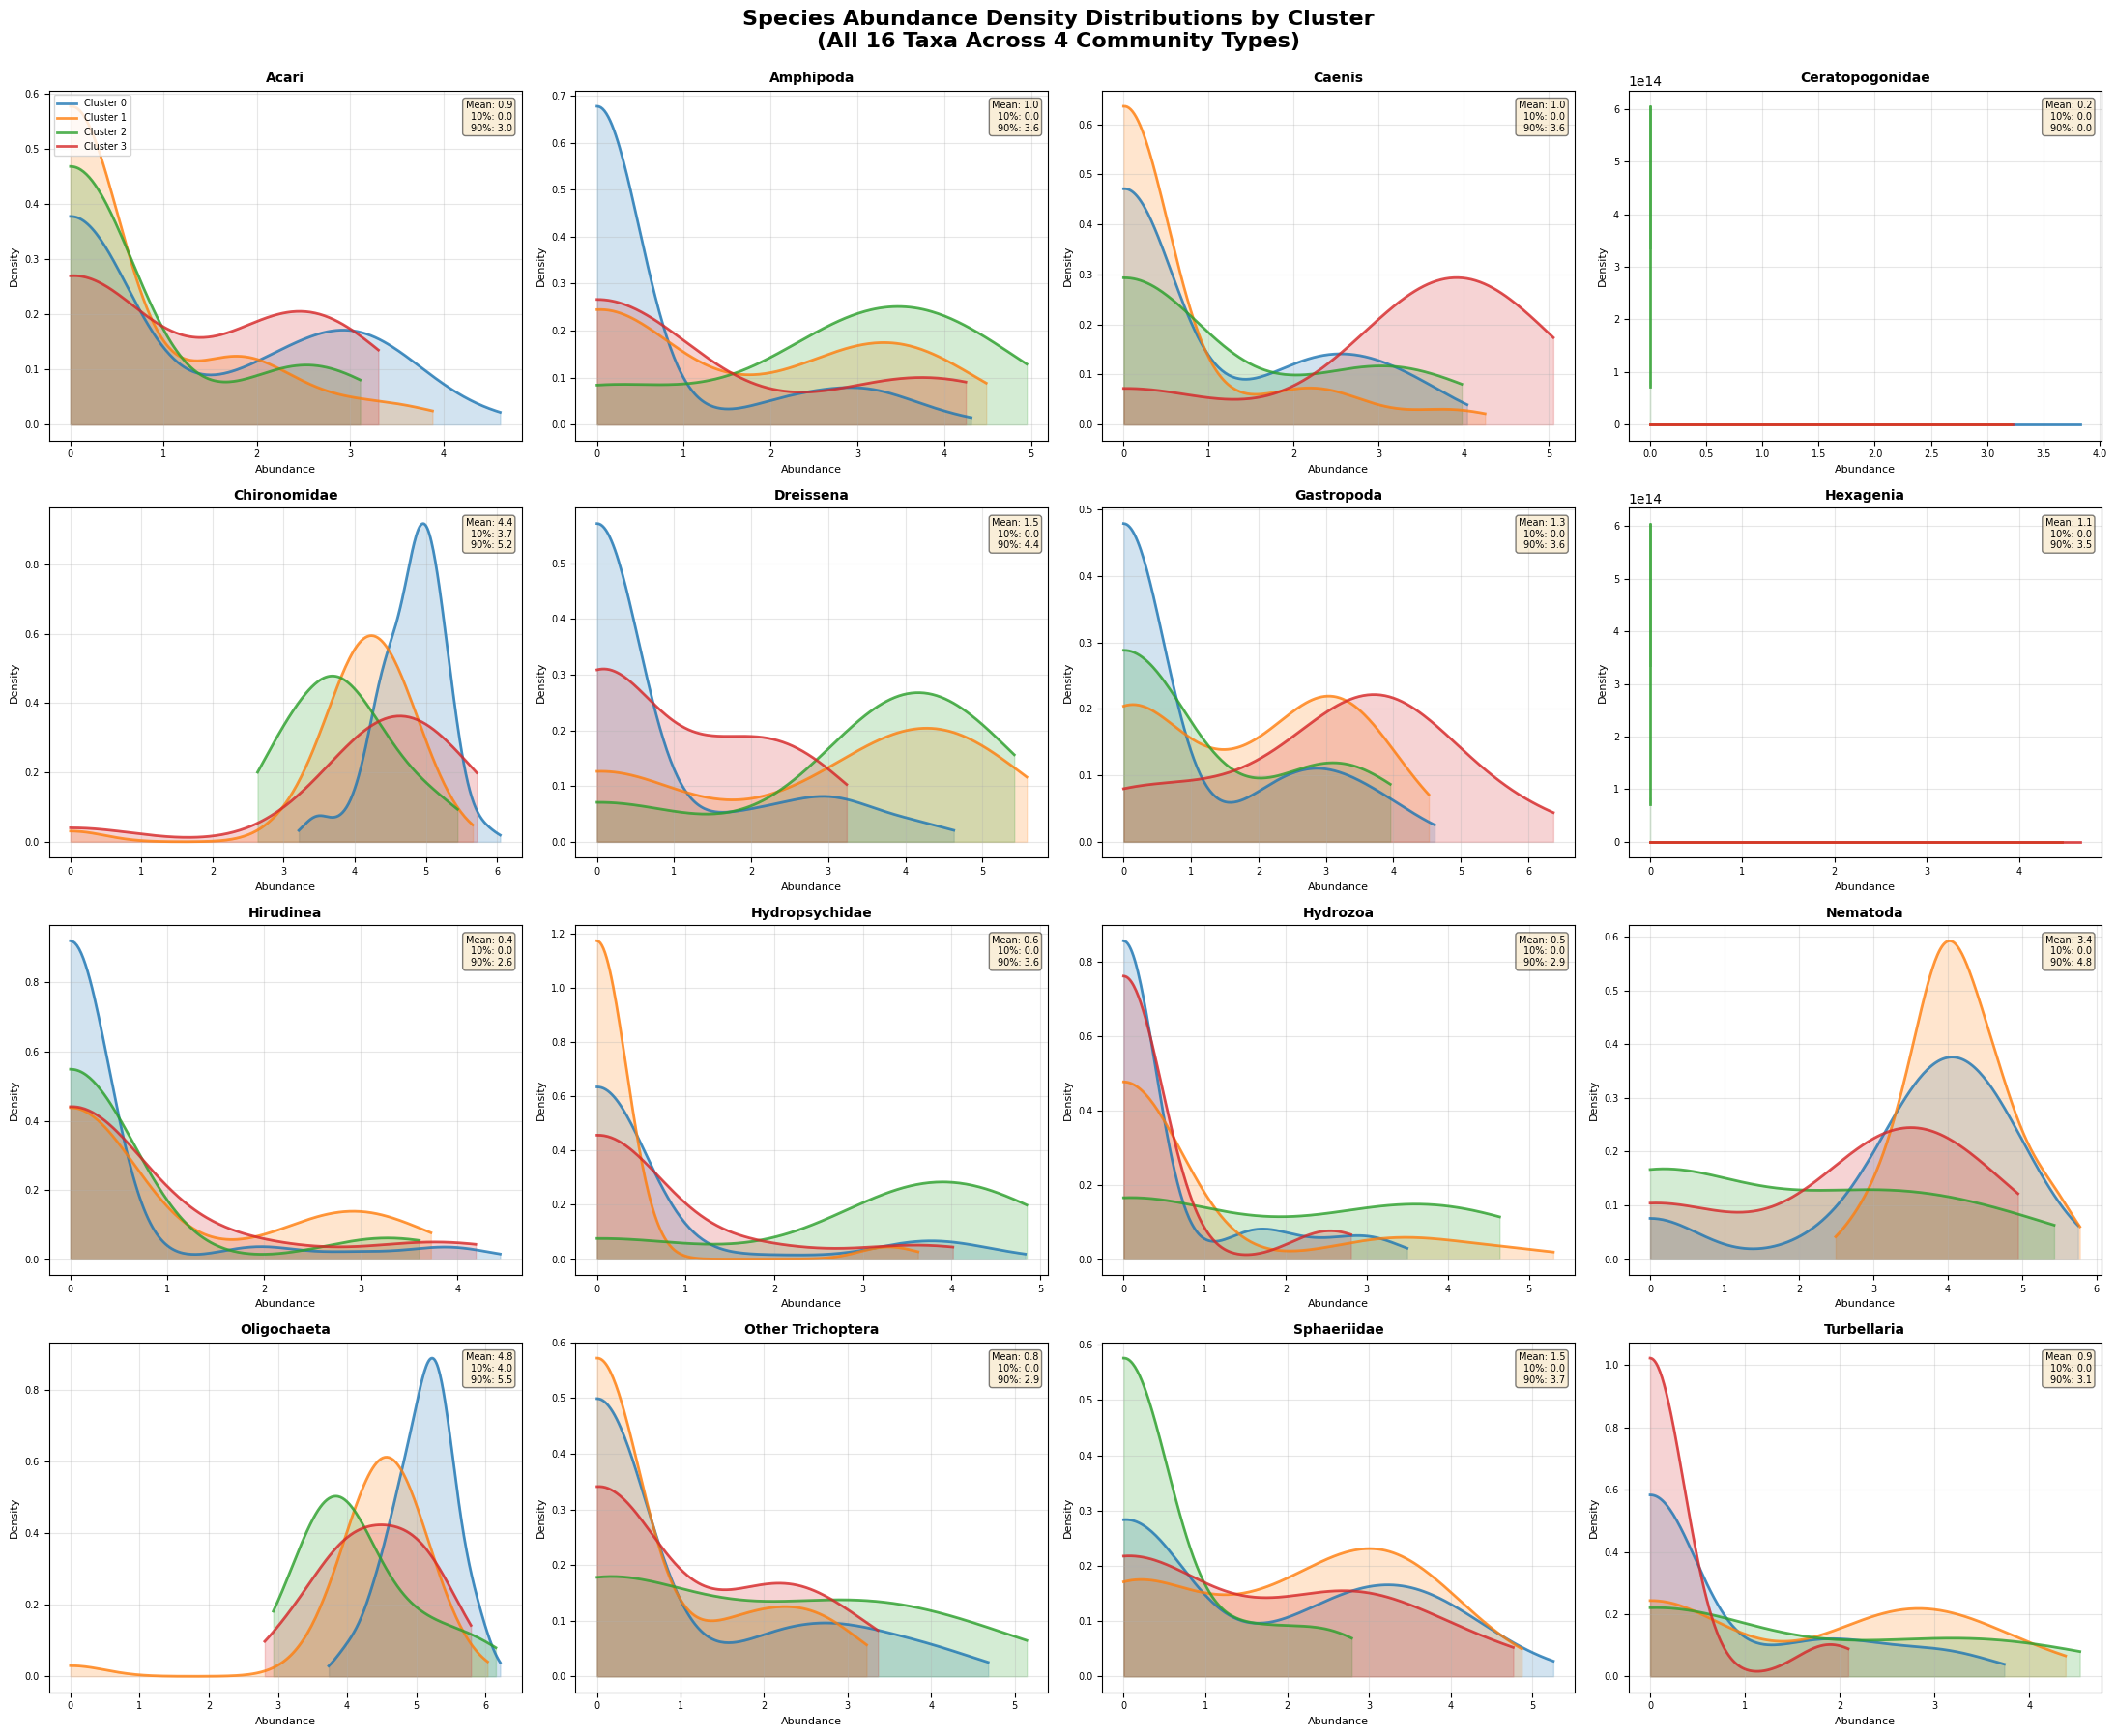


INTERPRETATION
Each subplot shows the density distribution of one species across clusters:
  - X-axis: Species abundance (raw counts)
  - Y-axis: Probability density
  - Different colors represent different clusters
  - Stats box shows: Mean, 10th percentile, 90th percentile (across all clusters)
  - For species with >80% zeros, density curves show non-zero values only
  - Peaks indicate typical abundance levels for that species in each cluster
  - Non-overlapping distributions suggest species differentiate clusters


In [39]:
# Create density plots for all 16 species across 4 clusters with improved handling
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Get species names
species_names = [col for col in species_by_cluster.columns if col != 'Cluster']
n_species = len(species_names)

# Create a large figure with subplots (4 rows x 4 columns for 16 species)
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

# Define colors for each cluster
cluster_colors = {0.0: '#1f77b4', 1.0: '#ff7f0e', 2.0: '#2ca02c', 3.0: '#d62728'}
clusters = sorted(species_by_cluster['Cluster'].unique())

# Plot density curves for each species
for idx, species in enumerate(species_names):
    ax = axes[idx]
    
    # Track if any data was plotted
    has_data = False
    
    for cluster in clusters:
        cluster_data = species_by_cluster[species_by_cluster['Cluster'] == cluster][species]
        
        # Filter out zeros for better density estimation if mostly zeros
        non_zero_data = cluster_data[cluster_data > 0]
        
        # Decide which data to use: if >80% zeros, use non-zero data; otherwise use all
        if len(non_zero_data) > 0 and (cluster_data == 0).sum() / len(cluster_data) > 0.8:
            plot_data = non_zero_data
        else:
            plot_data = cluster_data
        
        # Only plot if there's enough data and variance
        if len(plot_data) > 2 and plot_data.std() > 0:
            try:
                # Create kernel density estimate with bandwidth adjustment
                density = stats.gaussian_kde(plot_data, bw_method='scott')
                
                # Create x-range with some padding
                data_range = plot_data.max() - plot_data.min()
                x_min = max(0, plot_data.min() - 0.1 * data_range)
                x_max = plot_data.max() + 0.1 * data_range
                xs = np.linspace(x_min, x_max, 200)
                ys = density(xs)
                
                ax.plot(xs, ys, label=f'Cluster {int(cluster)}', 
                       color=cluster_colors[cluster], linewidth=2, alpha=0.8)
                ax.fill_between(xs, ys, alpha=0.2, color=cluster_colors[cluster])
                has_data = True
            except Exception as e:
                # If KDE fails, try histogram instead
                ax.hist(plot_data, bins=15, alpha=0.3, color=cluster_colors[cluster], 
                       density=True, label=f'Cluster {int(cluster)}')
                has_data = True
        elif len(plot_data) > 0:
            # If no variance, show as vertical line at the constant value
            ax.axvline(plot_data.iloc[0], color=cluster_colors[cluster], 
                      linestyle='--', linewidth=2, alpha=0.6, label=f'Cluster {int(cluster)}')
            has_data = True
    
    # Calculate and display statistics for all data (across all clusters)
    all_species_data = species_by_cluster[species]
    mean_val = all_species_data.mean()
    q10 = all_species_data.quantile(0.10)
    q90 = all_species_data.quantile(0.90)
    
    # Add text box with statistics
    stats_text = f'Mean: {mean_val:.1f}\n10%: {q10:.1f}\n90%: {q90:.1f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
            fontsize=7, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(species, fontsize=10, fontweight='bold')
    ax.set_xlabel('Abundance', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    
    if not has_data:
        ax.text(0.5, 0.5, 'No data or\ninsufficient variance', 
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='gray')
    
    # Only show legend on first subplot
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

# Overall title
fig.suptitle('Species Abundance Density Distributions by Cluster\n(All 16 Taxa Across 4 Community Types)', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("Each subplot shows the density distribution of one species across clusters:")
print("  - X-axis: Species abundance (raw counts)")
print("  - Y-axis: Probability density")
print("  - Different colors represent different clusters")
print("  - Stats box shows: Mean, 10th percentile, 90th percentile (across all clusters)")
print("  - For species with >80% zeros, density curves show non-zero values only")
print("  - Peaks indicate typical abundance levels for that species in each cluster")
print("  - Non-overlapping distributions suggest species differentiate clusters")

MEAN SPECIES ABUNDANCE BY CLUSTER

var      Acari  Amphipoda  Caenis  Ceratopogonidae  Chironomidae  Dreissena  Gastropoda  Hexagenia  Hirudinea  Hydropsychidae  Hydrozoa  Nematoda  Oligochaeta  Other Trichoptera  Sphaeriidae  Turbellaria
Cluster                                                                                                                                                                                                    
0.0       1.10       0.48    0.84             0.15          4.80       0.60        0.79       0.92       0.26            0.46      0.36      3.50         5.10               0.74         1.49         0.64
1.0       0.53       1.50    0.42             0.19          4.06       2.74        1.74       1.66       0.75            0.12      0.55      4.14         4.39               0.56         1.95         1.51
2.0       0.51       2.76    0.93             0.00          3.81       3.35        0.95       0.00       0.33            3.12      1.82      1.78    

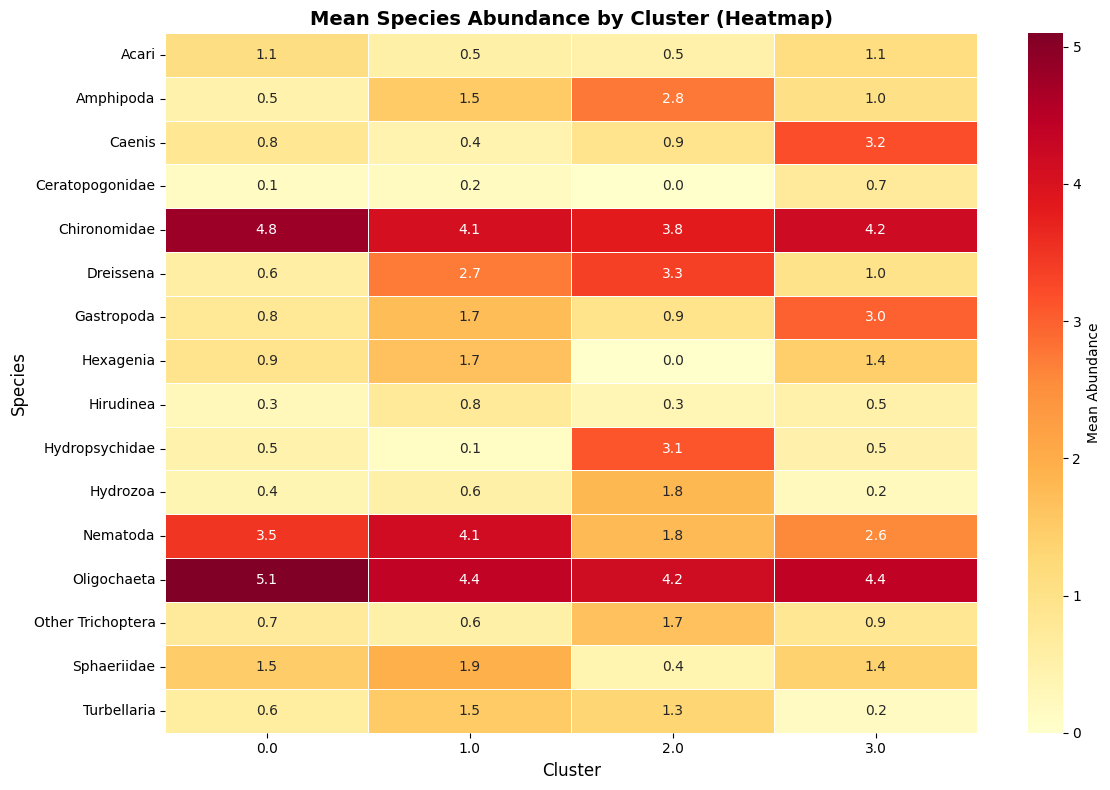

In [40]:
# Statistical summary: Mean abundance of each species by cluster
print("="*80)
print("MEAN SPECIES ABUNDANCE BY CLUSTER")
print("="*80)

# Calculate mean abundance for each species in each cluster
abundance_summary = species_by_cluster.groupby('Cluster')[species_names].mean()

# Display as a formatted table
print("\n" + abundance_summary.round(2).to_string())

# Identify characteristic species for each cluster (highest mean abundance)
print("\n" + "="*80)
print("CHARACTERISTIC SPECIES FOR EACH CLUSTER")
print("="*80)

for cluster in clusters:
    cluster_means = abundance_summary.loc[cluster].sort_values(ascending=False)
    top_species = cluster_means.head(5)
    
    print(f"\nCluster {int(cluster)} - Top 5 dominant species:")
    for species, abundance in top_species.items():
        print(f"  {species:<30} Mean abundance: {abundance:>8.2f}")

# Create a heatmap of mean species abundance by cluster
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(abundance_summary.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Abundance'}, ax=ax, linewidths=0.5)
ax.set_title('Mean Species Abundance by Cluster (Heatmap)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Species', fontsize=12)
plt.tight_layout()
plt.show()